# 🤖 E-Commerce Customer Churn: Model Training & Comparison

---

> **Phase 2 of the E-Commerce Customer Churn ML Pipeline**
> This notebook assumes Phase 1 (EDA + Preprocessing) is complete and the following artefacts exist:
> `processed_churn_data.csv` · `scaler.pkl` · `encoders.pkl`

---

| Attribute | Detail |
|-----------|--------|
| **Domain** | E-Commerce / Retail Analytics |
| **Problem Type** | Binary Classification — Customer Churn Prediction |
| **Models Trained** | 12 Algorithms (Logistic Regression → Naive Bayes) |
| **Evaluation** | Accuracy · Precision · Recall · F1 · ROC-AUC |
| **Tuning** | RandomizedSearchCV on Top-3 Models |
| **Explainability** | SHAP Summary + Bar Plots |
| **Outputs** | 12 Models · 3 Tuned Models · 4 CSV Reports |

---

## 📋 Notebook Sections

| # | Section | Description |
|---|---------|-------------|
| 1 | Environment Setup | Install packages, import libraries |
| 2 | Data Loading | Load processed data + artefacts |
| 3 | Train-Test Split | Stratified 80/20 split |
| 4 | Model Training & Evaluation | Train 12 models, compute metrics |
| 5 | Cross Validation | StratifiedKFold (k=5) for all models |
| 6 | Model Comparison | Leaderboard, ranking tables, plots |
| 7 | Hyperparameter Tuning | RandomizedSearchCV on Top-3 |
| 8 | Feature Importance | Tree-model feature importance + plots |
| 9 | SHAP Explainability | SHAP summary + bar plots on best model |
| 10 | Save All Models | Persist every trained model to disk |
| 11 | Final Report | Business interpretation + deployment rec. |

---

## ⚙️ Section 1 — Environment Setup

Install all required packages and configure the display environment.

---

In [1]:
# ── Install / upgrade required packages ──────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

required_packages = [
    "xgboost",
    "lightgbm",
    "catboost",
    "shap",
    "scikit-learn",
    "joblib",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
]

for pkg in required_packages:
    install(pkg)

print("✅ All packages installed / verified.")

✅ All packages installed / verified.


In [2]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib

# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn — Data splitting & metrics ───────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

# ── Scikit-learn — Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ── Gradient Boosting Frameworks ──────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Display helpers ───────────────────────────────────────────────────────────
from IPython.display import display, HTML
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#FAFAFA",
    "axes.facecolor":    "#FFFFFF",
    "axes.edgecolor":    "#CCCCCC",
    "axes.labelcolor":   "#333333",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "font.family":       "DejaVu Sans",
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

PALETTE_CHURN  = {0: "#2196F3", 1: "#F44336"}
COLOR_PRIMARY  = "#1565C0"
COLOR_ACCENT   = "#E53935"
COLOR_SUCCESS  = "#2E7D32"
COLOR_WARN     = "#F57F17"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully.")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}  |  seaborn {sns.__version__}")

✅ All libraries imported successfully.
   pandas 2.2.2  |  numpy 2.0.2  |  matplotlib 3.10.0  |  seaborn 0.13.2


## 📁 Section 1B — Output Directory Setup

Create the `models/` directory structure for saving all trained models.

---

In [3]:
# ── Create output directory for models ───────────────────────────────────────
os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

print("✅ Output directories created:")
print("   models/  — all trained model .pkl files")
print("   plots/   — all saved visualisations")

✅ Output directories created:
   models/  — all trained model .pkl files
   plots/   — all saved visualisations


## 📂 Section 2 — Data Loading

Load the pre-processed dataset and saved artefacts from Phase 1.

**Required input files (from Phase 1):**
- `processed_churn_data.csv` — fully cleaned, encoded, and scaled dataset
- `scaler.pkl` — fitted StandardScaler
- `encoders.pkl` — fitted Label + One-Hot encoders

---

In [4]:
# ── Load processed dataset ────────────────────────────────────────────────────
DATA_PATH    = "/content/processed_churn_data.csv"
SCALER_PATH  = "/content/scaler.pkl"
ENCODER_PATH = "/content/encoders.pkl"

# Verify files exist
for fpath in [DATA_PATH, SCALER_PATH, ENCODER_PATH]:
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f"❌  Required file not found: {fpath}\n"
            f"    Please run Phase 1 notebook first to generate this file."
        )
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  ✅  {fpath:<35s}  {size_kb:.1f} KB")

# Load dataset
df = pd.read_csv(DATA_PATH)

# Load artefacts
scaler   = joblib.load(SCALER_PATH)
encoders = joblib.load(ENCODER_PATH)

print()
print(f"Dataset shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target column    : Churn")
print(f"Churn distribution:\n{df['Churn'].value_counts().to_string()}")
print(f"Churn rate       : {df['Churn'].mean()*100:.2f}%")

  ✅  /content/processed_churn_data.csv    2914.7 KB
  ✅  /content/scaler.pkl                  2.0 KB
  ✅  /content/encoders.pkl                2.5 KB

Dataset shape    : 5,630 rows × 28 columns
Target column    : Churn
Churn distribution:
Churn
0    4682
1     948
Churn rate       : 16.84%


Dataset head (5 rows):


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,CustomerValueScore,OrderEngagementScore,LoyaltyScore,ComplaintRiskScore,CustomerActivityScore,AverageOrderBehaviorScore,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,Gender_Male,MaritalStatus_Married,MaritalStatus_Single
0,-1.7317,1,-0.7340,1.4698,-1.1464,0.3252,0.0927,-0.6729,-0.2619,-0.7730,1.8526,1.5843,-1.3018,-0.3859,-0.6814,0.1514,-0.3515,-1.2822,-0.6846,-1.8233,1.5528,-0.4711,-0.4281,1.0179,-0.5290,-1.2275,-1.0627,1.4611
1,-1.7311,1,-0.1357,-0.7153,-0.9067,1.7645,0.0927,0.3038,0.4467,-0.0484,1.0784,1.5843,-0.1879,-0.9243,-0.6814,-1.2490,-1.1447,-1.0191,0.7285,-1.2640,1.1513,0.5945,-0.2676,-0.9824,1.8904,0.8147,-1.0627,1.4611
2,-1.7305,1,-0.1357,-0.7153,1.7295,0.3252,-1.3249,0.3038,0.4467,-0.0484,0.6913,1.5843,-0.4664,-0.9243,-0.6814,-0.4087,-1.1573,-1.2337,0.4299,-1.2640,1.4613,-0.3210,-0.6309,-0.9824,1.8904,0.8147,-1.0627,1.4611
3,-1.7299,1,-1.2126,1.4698,-0.0679,0.3252,-1.3249,0.3038,-0.2619,1.4008,1.4655,-0.6312,2.0401,-0.9243,-0.6814,-0.4087,-0.8770,0.7771,0.4299,1.0142,-1.3285,-0.3210,1.6751,-0.9824,1.8904,0.8147,-1.0627,1.4611
4,-1.7293,1,-1.2126,-0.7153,-0.4274,-2.5535,0.0927,-0.6729,0.4467,1.4008,-0.4699,-0.6312,-1.3018,-0.3859,-0.6814,-0.4087,-0.9679,-1.5743,-0.4855,1.0142,-1.3707,-0.3210,-1.6130,-0.9824,1.8904,0.8147,-1.0627,1.4611



Dataset info:
  Shape         : (5630, 28)
  Memory usage  : 1231.7 KB
  Missing values: 0
  Dtypes:
float64    27
int64       1


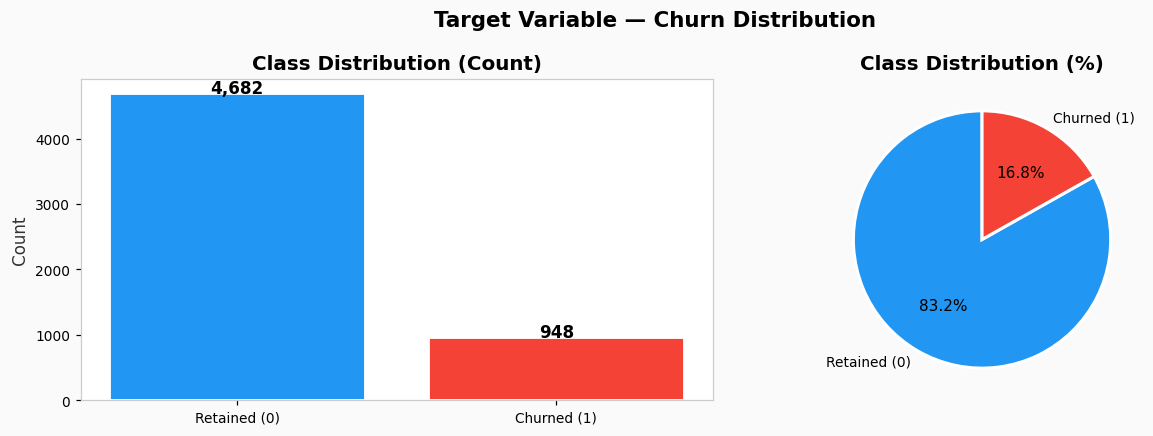


✅ Class distribution plotted.


In [5]:
# ── Quick dataset overview ─────────────────────────────────────────────────────
print("Dataset head (5 rows):")
display(df.head())

print("\nDataset info:")
print(f"  Shape         : {df.shape}")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Dtypes:\n{df.dtypes.value_counts().to_string()}")

# Class balance visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df["Churn"].value_counts()
churn_labels = ["Retained (0)", "Churned (1)"]

# Bar chart
axes[0].bar(churn_labels, churn_counts.values,
            color=[PALETTE_CHURN[0], PALETTE_CHURN[1]], edgecolor="white", linewidth=1.2)
axes[0].set_title("Class Distribution (Count)", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(churn_counts.values,
            labels=churn_labels,
            colors=[PALETTE_CHURN[0], PALETTE_CHURN[1]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Distribution (%)", fontweight="bold")

plt.suptitle("Target Variable — Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Class distribution plotted.")

## ✂️ Section 3 — Train-Test Split

Stratified 80/20 split to preserve class proportions in both sets.

| Parameter | Value |
|-----------|-------|
| Test size | 20% |
| Stratify | Yes (on `Churn`) |
| Random state | 42 |

---

In [6]:
# ── Separate features and target ─────────────────────────────────────────────
TARGET = "Churn"
FEATURES = [col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"Target   (y): {y.shape[0]} rows")
print(f"Feature names: {list(X.columns)}")

Features (X): 27 columns
Target   (y): 5630 rows
Feature names: ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'CustomerValueScore', 'OrderEngagementScore', 'LoyaltyScore', 'ComplaintRiskScore', 'CustomerActivityScore', 'AverageOrderBehaviorScore', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [7]:
# ── Stratified Train-Test Split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 55)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 55)
print(f"  Training set   : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Test set       : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"  Features       : {X_train.shape[1]}")
print()
print("  Class distribution (Train):")
print(f"    Retained (0) : {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"    Churned  (1) : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")
print()
print("  Class distribution (Test):")
print(f"    Retained (0) : {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")
print(f"    Churned  (1) : {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")
print()
print("  ✅ Stratified split preserves class ratios — verified.")

  TRAIN-TEST SPLIT SUMMARY
  Training set   : 4,504 samples  (80.0%)
  Test set       : 1,126 samples  (20.0%)
  Features       : 27

  Class distribution (Train):
    Retained (0) : 3,746  (83.2%)
    Churned  (1) : 758  (16.8%)

  Class distribution (Test):
    Retained (0) : 936  (83.1%)
    Churned  (1) : 190  (16.9%)

  ✅ Stratified split preserves class ratios — verified.


## 🏗️ Section 4 — Model Registry & Helper Functions

Define all 12 classifiers and the evaluation helper that computes all metrics.

---

In [8]:
# ── Model registry — all 12 classifiers ──────────────────────────────────────
MODEL_REGISTRY = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        class_weight="balanced", n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        class_weight="balanced", n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        eval_metric="logloss", verbosity=0,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        class_weight="balanced", verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, random_state=RANDOM_STATE,
        verbose=0, auto_class_weights="Balanced"
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7, n_jobs=-1
    ),
    "Support Vector Machine": SVC(
        probability=True, random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Naive Bayes": GaussianNB(),
}

# ── Model file mapping ────────────────────────────────────────────────────────
MODEL_FILENAMES = {
    "Logistic Regression"    : "models/logistic_regression.pkl",
    "Decision Tree"          : "models/decision_tree.pkl",
    "Random Forest"          : "models/random_forest.pkl",
    "Extra Trees"            : "models/extra_trees.pkl",
    "AdaBoost"               : "models/adaboost.pkl",
    "Gradient Boosting"      : "models/gradient_boosting.pkl",
    "XGBoost"                : "models/xgboost.pkl",
    "LightGBM"               : "models/lightgbm.pkl",
    "CatBoost"               : "models/catboost.pkl",
    "K-Nearest Neighbors"    : "models/knn.pkl",
    "Support Vector Machine" : "models/svm.pkl",
    "Naive Bayes"            : "models/naive_bayes.pkl",
}

print(f"✅ Model registry initialised with {len(MODEL_REGISTRY)} classifiers:")
for i, name in enumerate(MODEL_REGISTRY.keys(), 1):
    print(f"   {i:02d}. {name}")

✅ Model registry initialised with 12 classifiers:
   01. Logistic Regression
   02. Decision Tree
   03. Random Forest
   04. Extra Trees
   05. AdaBoost
   06. Gradient Boosting
   07. XGBoost
   08. LightGBM
   09. CatBoost
   10. K-Nearest Neighbors
   11. Support Vector Machine
   12. Naive Bayes


In [10]:
# ── Evaluation helper function ────────────────────────────────────────────────

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train a model, predict on test set, and return evaluation metrics.
    """

    # Train
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # Predict
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    # Metrics
    metrics = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "F1 Score": round(f1_score(y_te, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_te, y_proba), 4),
        "Train Time (s)": round(train_time, 3),
    }

    return metrics, model, y_pred, y_proba


print("✅ evaluate_model() helper function defined.")


# ── Confusion Matrix Helper ───────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    """
    Plot a styled confusion matrix on the given axes.
    """

    cm = confusion_matrix(y_true, y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Retained", "Churned"],
        yticklabels=["Retained", "Churned"],
        ax=ax,
        linewidths=0.5
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(
        f"{model_name}\nConfusion Matrix",
        fontsize=10,
        fontweight="bold"
    )


print("✅ plot_confusion_matrix() helper defined.")

✅ evaluate_model() helper function defined.
✅ plot_confusion_matrix() helper defined.


## 🚀 Section 4 — Model Training & Evaluation

Train all 12 classifiers and compute metrics on the held-out test set.

**Metrics computed per model:**
| Metric | Description |
|--------|-------------|
| **Accuracy** | Overall correct predictions / total |
| **Precision** | TP / (TP + FP) — quality of positive predictions |
| **Recall** | TP / (TP + FN) — coverage of actual positives |
| **F1 Score** | Harmonic mean of Precision and Recall |
| **ROC AUC** | Area under the Receiver Operating Characteristic curve |

---

In [11]:
# ── Train all 12 models and collect results ───────────────────────────────────
all_results   = []     # list of metric dicts
trained_models = {}    # name -> fitted model
predictions    = {}    # name -> (y_pred, y_proba)

print("=" * 70)
print("  TRAINING 12 CLASSIFIERS")
print("=" * 70)

for i, (name, model) in enumerate(MODEL_REGISTRY.items(), 1):
    print(f"\n[{i:02d}/{len(MODEL_REGISTRY)}] Training: {name} ...", end=" ", flush=True)
    try:
        metrics, fitted_model, y_pred, y_proba = evaluate_model(
            name, model, X_train, y_train, X_test, y_test
        )
        all_results.append(metrics)
        trained_models[name] = fitted_model
        predictions[name]    = (y_pred, y_proba)
        print(f"✅  Accuracy={metrics['Accuracy']:.4f}  |  ROC AUC={metrics['ROC AUC']:.4f}  |  F1={metrics['F1 Score']:.4f}  |  [{metrics['Train Time (s)']}s]")
    except Exception as e:
        print(f"❌ FAILED — {e}")

print()
print("=" * 70)
print(f"  Training complete: {len(trained_models)}/{len(MODEL_REGISTRY)} models successful.")
print("=" * 70)

  TRAINING 12 CLASSIFIERS

[01/12] Training: Logistic Regression ... ✅  Accuracy=0.7780  |  ROC AUC=0.8699  |  F1=0.5520  |  [0.074s]

[02/12] Training: Decision Tree ... ✅  Accuracy=0.9503  |  ROC AUC=0.9009  |  F1=0.8486  |  [0.106s]

[03/12] Training: Random Forest ... ✅  Accuracy=0.9636  |  ROC AUC=0.9958  |  F1=0.8818  |  [3.113s]

[04/12] Training: Extra Trees ... ✅  Accuracy=0.9734  |  ROC AUC=0.9978  |  F1=0.9157  |  [1.504s]

[05/12] Training: AdaBoost ... ✅  Accuracy=0.8890  |  ROC AUC=0.9084  |  F1=0.6082  |  [0.935s]

[06/12] Training: Gradient Boosting ... ✅  Accuracy=0.9281  |  ROC AUC=0.9567  |  F1=0.7625  |  [4.636s]

[07/12] Training: XGBoost ... ✅  Accuracy=0.9822  |  ROC AUC=0.9967  |  F1=0.9468  |  [0.668s]

[08/12] Training: LightGBM ... ✅  Accuracy=0.9840  |  ROC AUC=0.9988  |  F1=0.9526  |  [0.462s]

[09/12] Training: CatBoost ... ✅  Accuracy=0.9512  |  ROC AUC=0.9905  |  F1=0.8681  |  [0.933s]

[10/12] Training: K-Nearest Neighbors ... ✅  Accuracy=0.8810  |  ROC

In [12]:
# ── Build master comparison dataframe ────────────────────────────────────────
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("ROC AUC", ascending=False).reset_index(drop=True)
df_results.index = df_results.index + 1   # 1-based rank

print("\n📊 MASTER MODEL COMPARISON TABLE")
print("=" * 78)
display(df_results.style
    .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"], cmap="Greens")
    .format({
        "Accuracy"  : "{:.4f}",
        "Precision" : "{:.4f}",
        "Recall"    : "{:.4f}",
        "F1 Score"  : "{:.4f}",
        "ROC AUC"   : "{:.4f}",
        "Train Time (s)": "{:.3f}",
    })
    .set_caption("Model Performance on Test Set (sorted by ROC AUC)")
)


📊 MASTER MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Train Time (s)
1,LightGBM,0.9840,0.9526,0.9526,0.9526,0.9988,0.462
2,Extra Trees,0.9734,0.9819,0.8579,0.9157,0.9978,1.504
3,XGBoost,0.9822,0.9570,0.9368,0.9468,0.9967,0.668
4,Random Forest,0.9636,0.9745,0.8053,0.8818,0.9958,3.113
5,CatBoost,0.9512,0.7974,0.9526,0.8681,0.9905,0.933
6,Gradient Boosting,0.9281,0.8609,0.6842,0.7625,0.9567,4.636
7,Support Vector Machine,0.8748,0.5842,0.8947,0.7069,0.9414,4.145
8,AdaBoost,0.8890,0.7519,0.5105,0.6082,0.9084,0.935
9,K-Nearest Neighbors,0.8810,0.7500,0.4421,0.5563,0.9035,0.003
10,Decision Tree,0.9503,0.8722,0.8263,0.8486,0.9009,0.106


### 4A — Individual Model Classification Reports

Detailed precision/recall/f1 per class for each model.

---

In [13]:
# ── Print classification report for every model ──────────────────────────────
for name, (y_pred, _) in predictions.items():
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred,
                                target_names=["Retained (0)", "Churned (1)"]))

  Logistic Regression
              precision    recall  f1-score   support

Retained (0)       0.95      0.77      0.85       936
 Churned (1)       0.42      0.81      0.55       190

    accuracy                           0.78      1126
   macro avg       0.69      0.79      0.70      1126
weighted avg       0.86      0.78      0.80      1126

  Decision Tree
              precision    recall  f1-score   support

Retained (0)       0.97      0.98      0.97       936
 Churned (1)       0.87      0.83      0.85       190

    accuracy                           0.95      1126
   macro avg       0.92      0.90      0.91      1126
weighted avg       0.95      0.95      0.95      1126

  Random Forest
              precision    recall  f1-score   support

Retained (0)       0.96      1.00      0.98       936
 Churned (1)       0.97      0.81      0.88       190

    accuracy                           0.96      1126
   macro avg       0.97      0.90      0.93      1126
weighted avg       0

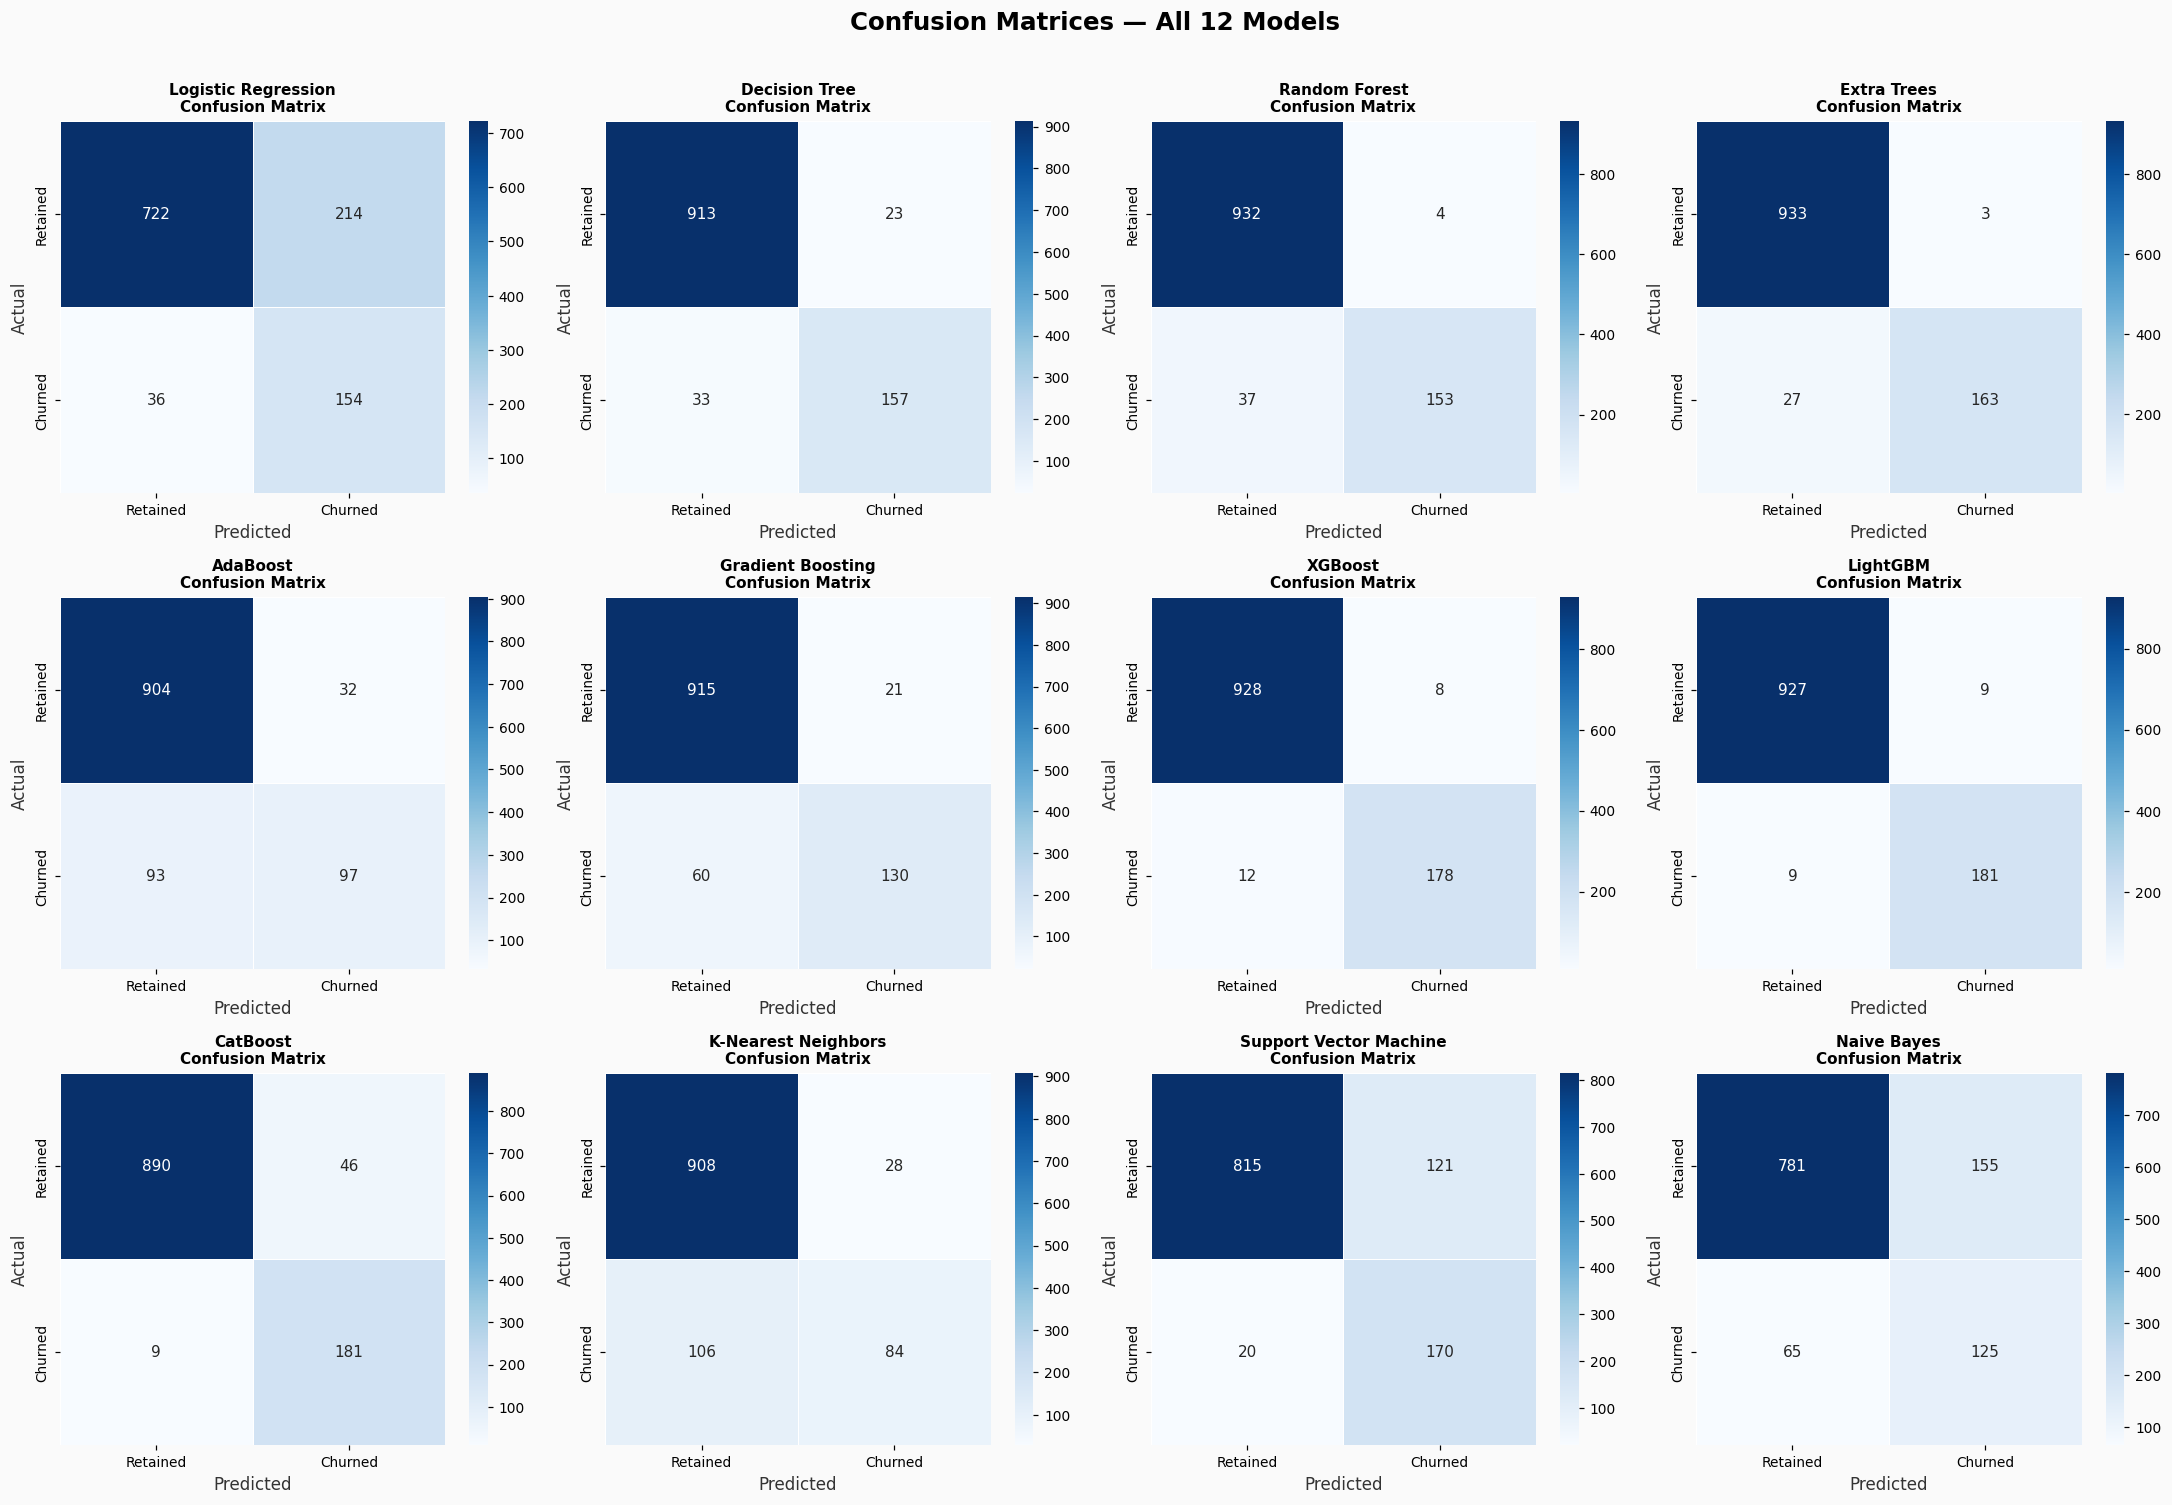

✅ Confusion matrix grid saved.


In [14]:
# ── Confusion matrices — all 12 models in a 4×3 grid ─────────────────────────
n_models = len(predictions)
n_cols   = 4
n_rows   = -(-n_models // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4.5))
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(predictions.items()):
    plot_confusion_matrix(y_test, y_pred, name, ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All 12 Models", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix grid saved.")

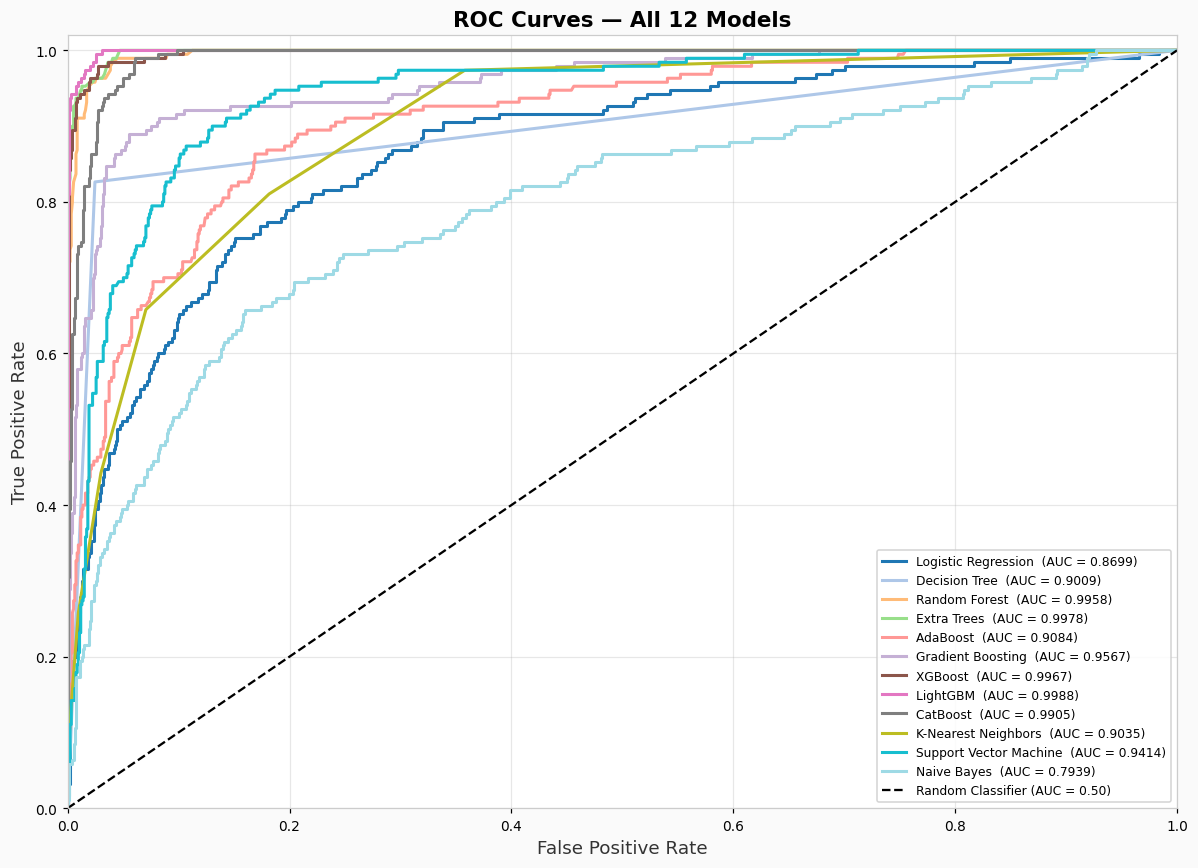

✅ ROC curve comparison plot saved.


In [15]:
# ── ROC Curves — all 12 models on a single plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(predictions)))

for (name, (_, y_proba)), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name}  (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All 12 Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=8, framealpha=0.85)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("plots/roc_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curve comparison plot saved.")

## 🔁 Section 5 — Cross Validation

Stratified K-Fold cross validation on every model to assess stability.

| Parameter | Value |
|-----------|-------|
| Method | StratifiedKFold |
| n_splits | 5 |
| Metric | Accuracy |
| Scoring | Mean ± Standard Deviation |

---

In [16]:
# ── StratifiedKFold Cross Validation — all 12 models ─────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

print("Running 5-Fold Stratified Cross Validation...")
print("=" * 65)

for name, model in MODEL_REGISTRY.items():
    # Re-instantiate to avoid data leakage from the training loop
    # (use same hyperparameters)
    cv_model = MODEL_REGISTRY[name]

    try:
        scores = cross_val_score(cv_model, X, y,
                                 cv=skf,
                                 scoring="accuracy",
                                 n_jobs=-1)
        result = {
            "Model"             : name,
            "CV Mean Accuracy"  : round(scores.mean(), 4),
            "CV Std"            : round(scores.std(),  4),
            "CV Min"            : round(scores.min(),  4),
            "CV Max"            : round(scores.max(),  4),
            "95% CI Lower"      : round(scores.mean() - 2 * scores.std(), 4),
            "95% CI Upper"      : round(scores.mean() + 2 * scores.std(), 4),
        }
        cv_results.append(result)
        print(f"  {name:<28s}  Mean={scores.mean():.4f}  ±{scores.std():.4f}  "
              f"[Min={scores.min():.4f}, Max={scores.max():.4f}]")
    except Exception as e:
        print(f"  {name:<28s}  ❌ Failed: {e}")

print()
print("✅ Cross validation complete.")

Running 5-Fold Stratified Cross Validation...
  Logistic Regression           Mean=0.7909  ±0.0134  [Min=0.7691, Max=0.8073]
  Decision Tree                 Mean=0.9311  ±0.0115  [Min=0.9174, Max=0.9440]
  Random Forest                 Mean=0.9533  ±0.0077  [Min=0.9405, Max=0.9627]
  Extra Trees                   Mean=0.9652  ±0.0053  [Min=0.9547, Max=0.9689]
  AdaBoost                      Mean=0.8936  ±0.0074  [Min=0.8837, Max=0.9014]
  Gradient Boosting             Mean=0.9266  ±0.0075  [Min=0.9147, Max=0.9352]
  XGBoost                       Mean=0.9744  ±0.0053  [Min=0.9645, Max=0.9787]
  LightGBM                      Mean=0.9746  ±0.0040  [Min=0.9698, Max=0.9787]
  CatBoost                      Mean=0.9478  ±0.0065  [Min=0.9396, Max=0.9591]
  K-Nearest Neighbors           Mean=0.8845  ±0.0054  [Min=0.8783, Max=0.8943]
  Support Vector Machine        Mean=0.8822  ±0.0095  [Min=0.8686, Max=0.8970]
  Naive Bayes                   Mean=0.8107  ±0.0156  [Min=0.7877, Max=0.8330]

✅ Cro

In [17]:
# ── Cross Validation Results Table ───────────────────────────────────────────
df_cv = pd.DataFrame(cv_results)
df_cv = df_cv.sort_values("CV Mean Accuracy", ascending=False).reset_index(drop=True)
df_cv.index = df_cv.index + 1

print("\n📊 CROSS VALIDATION RESULTS TABLE")
display(df_cv.style
    .background_gradient(subset=["CV Mean Accuracy"], cmap="Blues")
    .bar(subset=["CV Std"], color="#FF7043", vmin=0)
    .format({
        "CV Mean Accuracy" : "{:.4f}",
        "CV Std"           : "{:.4f}",
        "CV Min"           : "{:.4f}",
        "CV Max"           : "{:.4f}",
        "95% CI Lower"     : "{:.4f}",
        "95% CI Upper"     : "{:.4f}",
    })
    .set_caption("5-Fold Stratified Cross Validation Results")
)

# Save to CSV
df_cv.to_csv("cross_validation_results.csv", index=True, index_label="Rank")
print("\n✅ cross_validation_results.csv saved.")


📊 CROSS VALIDATION RESULTS TABLE


,Model,CV Mean Accuracy,CV Std,CV Min,CV Max,95% CI Lower,95% CI Upper
1,LightGBM,0.9746,0.0040,0.9698,0.9787,0.9665,0.9827
2,XGBoost,0.9744,0.0053,0.9645,0.9787,0.9638,0.9850
3,Extra Trees,0.9652,0.0053,0.9547,0.9689,0.9546,0.9758
4,Random Forest,0.9533,0.0077,0.9405,0.9627,0.9379,0.9686
5,CatBoost,0.9478,0.0065,0.9396,0.9591,0.9348,0.9608
6,Decision Tree,0.9311,0.0115,0.9174,0.9440,0.9080,0.9541
7,Gradient Boosting,0.9266,0.0075,0.9147,0.9352,0.9116,0.9417
8,AdaBoost,0.8936,0.0074,0.8837,0.9014,0.8787,0.9085
9,K-Nearest Neighbors,0.8845,0.0054,0.8783,0.8943,0.8738,0.8953
10,Support Vector Machine,0.8822,0.0095,0.8686,0.8970,0.8633,0.9012



✅ cross_validation_results.csv saved.


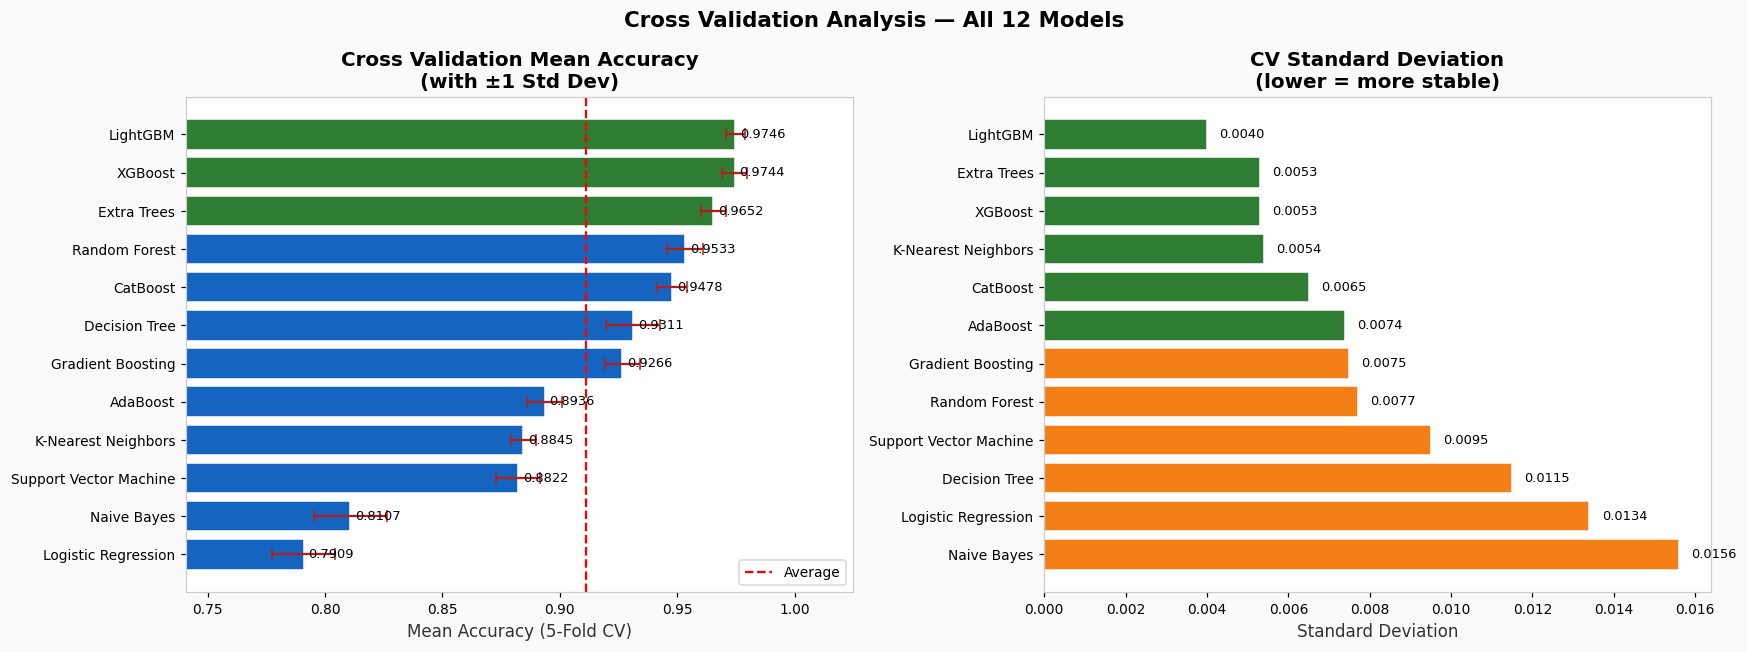

✅ CV plot saved.


In [18]:
# ── CV Mean Accuracy with Error Bars ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by mean accuracy
df_cv_plot = df_cv.sort_values("CV Mean Accuracy", ascending=True)

# Left: Horizontal bar chart with error bars
colors_cv = [COLOR_SUCCESS if i >= len(df_cv_plot) - 3 else COLOR_PRIMARY
             for i in range(len(df_cv_plot))]
bars = axes[0].barh(df_cv_plot["Model"], df_cv_plot["CV Mean Accuracy"],
                    xerr=df_cv_plot["CV Std"],
                    color=colors_cv, edgecolor="white", capsize=4,
                    error_kw={"ecolor": "#B71C1C", "linewidth": 1.5})
axes[0].set_xlabel("Mean Accuracy (5-Fold CV)", fontsize=11)
axes[0].set_title("Cross Validation Mean Accuracy\n(with ±1 Std Dev)", fontweight="bold")
axes[0].axvline(df_cv_plot["CV Mean Accuracy"].mean(), color="red",
                linestyle="--", lw=1.5, label="Average")
for bar, val in zip(bars, df_cv_plot["CV Mean Accuracy"]):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=8.5)
axes[0].legend()
axes[0].set_xlim([df_cv_plot["CV Mean Accuracy"].min() - 0.05,
                   df_cv_plot["CV Mean Accuracy"].max() + 0.05])

# Right: CV Std (stability) — lower is better
df_cv_std = df_cv.sort_values("CV Std", ascending=False)
colors_std = [COLOR_WARN if v > df_cv["CV Std"].median() else COLOR_SUCCESS
              for v in df_cv_std["CV Std"]]
bars2 = axes[1].barh(df_cv_std["Model"], df_cv_std["CV Std"],
                     color=colors_std, edgecolor="white")
axes[1].set_xlabel("Standard Deviation", fontsize=11)
axes[1].set_title("CV Standard Deviation\n(lower = more stable)", fontweight="bold")
for bar, val in zip(bars2, df_cv_std["CV Std"]):
    axes[1].text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=8.5)

plt.suptitle("Cross Validation Analysis — All 12 Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/cross_validation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ CV plot saved.")

## 📊 Section 6 — Model Comparison

Generate ranked leaderboards and multi-metric comparison charts.

---

In [19]:
# ── Full comparison + ranking table ──────────────────────────────────────────
df_compare = df_results.copy().reset_index(drop=True)

# Add ranks per metric
for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
    df_compare[f"{metric} Rank"] = df_compare[metric].rank(ascending=False).astype(int)

# Overall rank = average of individual ranks
rank_cols = [c for c in df_compare.columns if "Rank" in c]
df_compare["Overall Rank"] = df_compare[rank_cols].mean(axis=1).rank().astype(int)
df_compare = df_compare.sort_values("Overall Rank")

print("\n🏆 MODEL LEADERBOARD — RANKED BY OVERALL PERFORMANCE")
print("=" * 80)
display(df_compare[[
    "Model", "Overall Rank",
    "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"
]].style
    .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"], cmap="RdYlGn")
    .format({
        "Accuracy"    : "{:.4f}",
        "Precision"   : "{:.4f}",
        "Recall"      : "{:.4f}",
        "F1 Score"    : "{:.4f}",
        "ROC AUC"     : "{:.4f}",
        "Overall Rank": "{:.0f}",
    })
    .set_caption("Full Model Leaderboard — All 12 Classifiers")
)

df_compare.to_csv("model_comparison.csv", index=False)
print("\n✅ model_comparison.csv saved.")


🏆 MODEL LEADERBOARD — RANKED BY OVERALL PERFORMANCE


,Model,Overall Rank,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,1,0.9840,0.9526,0.9526,0.9526,0.9988
2,XGBoost,2,0.9822,0.9570,0.9368,0.9468,0.9967
1,Extra Trees,3,0.9734,0.9819,0.8579,0.9157,0.9978
3,Random Forest,4,0.9636,0.9745,0.8053,0.8818,0.9958
4,CatBoost,5,0.9512,0.7974,0.9526,0.8681,0.9905
9,Decision Tree,6,0.9503,0.8722,0.8263,0.8486,0.9009
5,Gradient Boosting,7,0.9281,0.8609,0.6842,0.7625,0.9567
6,Support Vector Machine,8,0.8748,0.5842,0.8947,0.7069,0.9414
7,AdaBoost,9,0.8890,0.7519,0.5105,0.6082,0.9084
8,K-Nearest Neighbors,10,0.8810,0.7500,0.4421,0.5563,0.9035



✅ model_comparison.csv saved.


In [20]:
# ── Identify Top 3 models ─────────────────────────────────────────────────────
top3 = df_compare.head(3)["Model"].tolist()

BEST_MODEL  = top3[0]
SECOND_MODEL = top3[1]
THIRD_MODEL  = top3[2]

print("=" * 55)
print("  TOP MODEL RANKING")
print("=" * 55)
for rank, name in enumerate(top3, 1):
    medal = ["🥇", "🥈", "🥉"][rank-1]
    row = df_compare[df_compare["Model"] == name].iloc[0]
    print(f"  {medal} Rank {rank}: {name}")
    print(f"         Accuracy={row['Accuracy']:.4f}  |  ROC AUC={row['ROC AUC']:.4f}  |  F1={row['F1 Score']:.4f}")
    print()

print(f"  🏆 Best Model        : {BEST_MODEL}")
print(f"  🥈 2nd Best Model    : {SECOND_MODEL}")
print(f"  🥉 3rd Best Model    : {THIRD_MODEL}")

  TOP MODEL RANKING
  🥇 Rank 1: LightGBM
         Accuracy=0.9840  |  ROC AUC=0.9988  |  F1=0.9526

  🥈 Rank 2: XGBoost
         Accuracy=0.9822  |  ROC AUC=0.9967  |  F1=0.9468

  🥉 Rank 3: Extra Trees
         Accuracy=0.9734  |  ROC AUC=0.9978  |  F1=0.9157

  🏆 Best Model        : LightGBM
  🥈 2nd Best Model    : XGBoost
  🥉 3rd Best Model    : Extra Trees


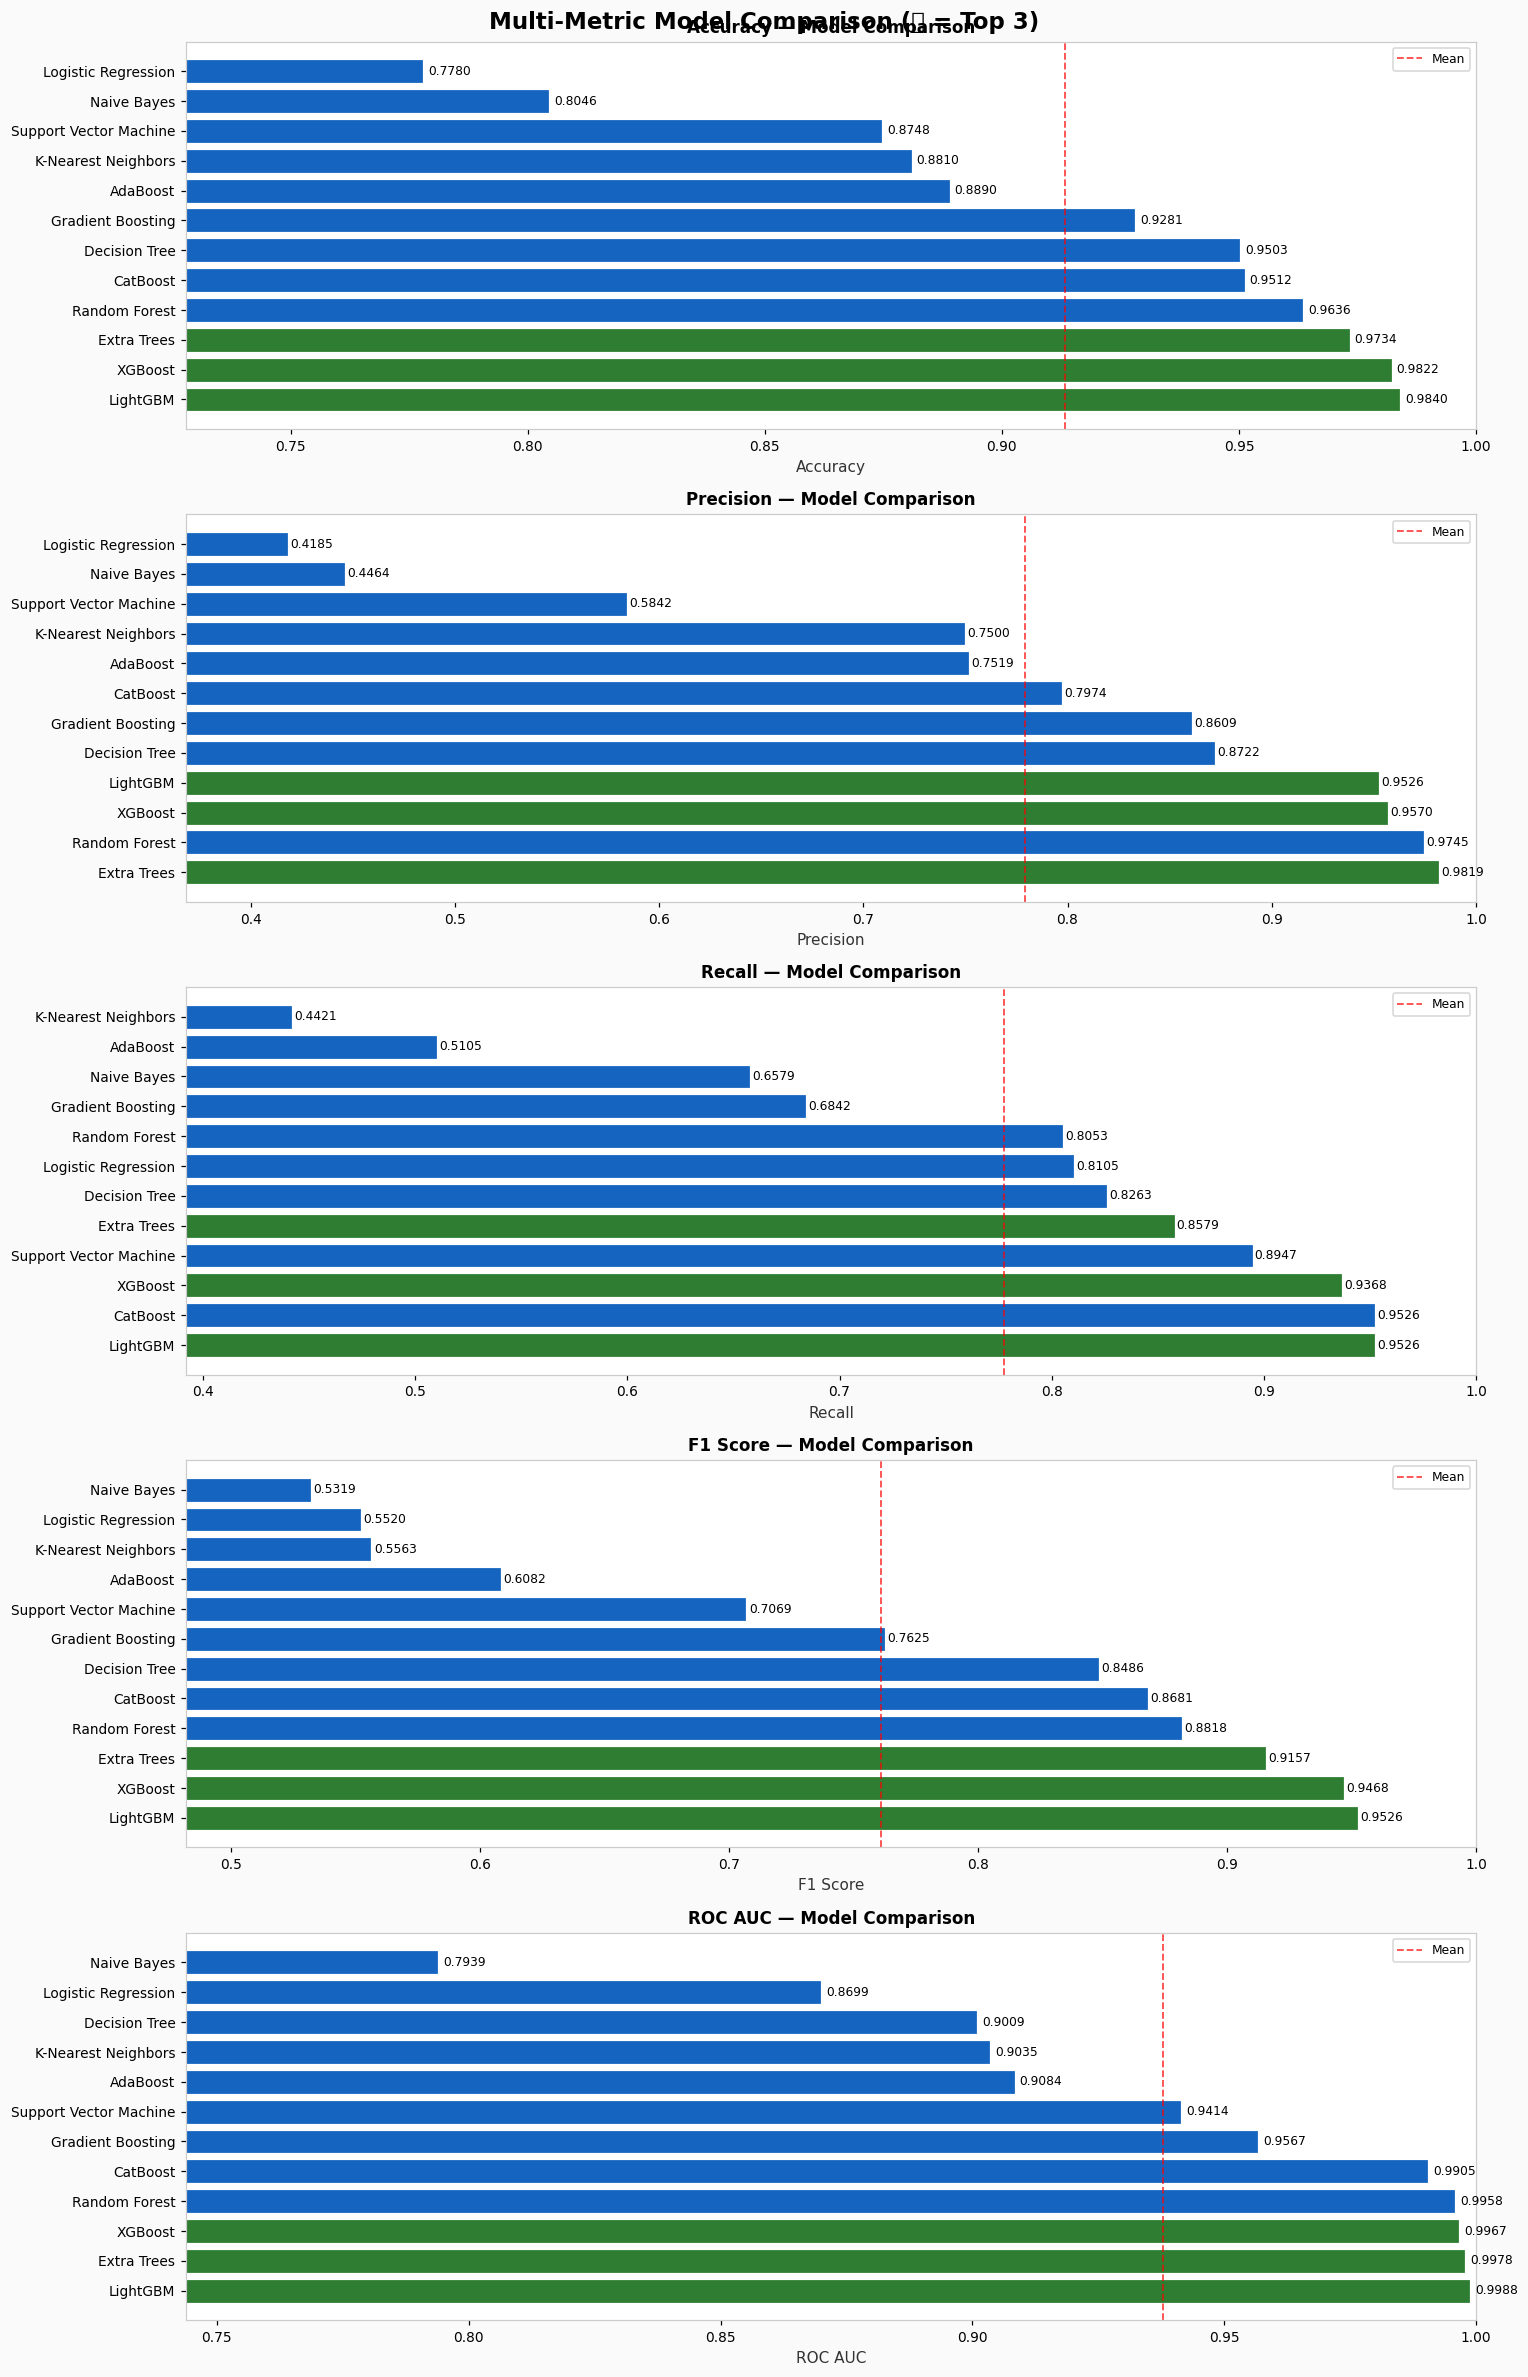

✅ Multi-metric comparison chart saved.


In [21]:
# ── Multi-metric comparison bar chart ────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
df_plot = df_results.set_index("Model")[metrics_to_plot]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(14, 22))

for i, metric in enumerate(metrics_to_plot):
    sorted_data = df_plot[metric].sort_values(ascending=False)
    colors = [COLOR_SUCCESS if name in top3 else COLOR_PRIMARY for name in sorted_data.index]
    bars = axes[i].barh(sorted_data.index, sorted_data.values,
                        color=colors, edgecolor="white", linewidth=0.8)
    axes[i].set_xlabel(metric, fontsize=10)
    axes[i].set_title(f"{metric} — Model Comparison", fontweight="bold", fontsize=11)
    axes[i].set_xlim([max(0, sorted_data.min() - 0.05), min(1.0, sorted_data.max() + 0.05)])
    axes[i].axvline(sorted_data.mean(), color="red", linestyle="--", lw=1.2, alpha=0.7, label="Mean")
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, sorted_data.values):
        axes[i].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                     f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("Multi-Metric Model Comparison (🟢 = Top 3)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/model_comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Multi-metric comparison chart saved.")

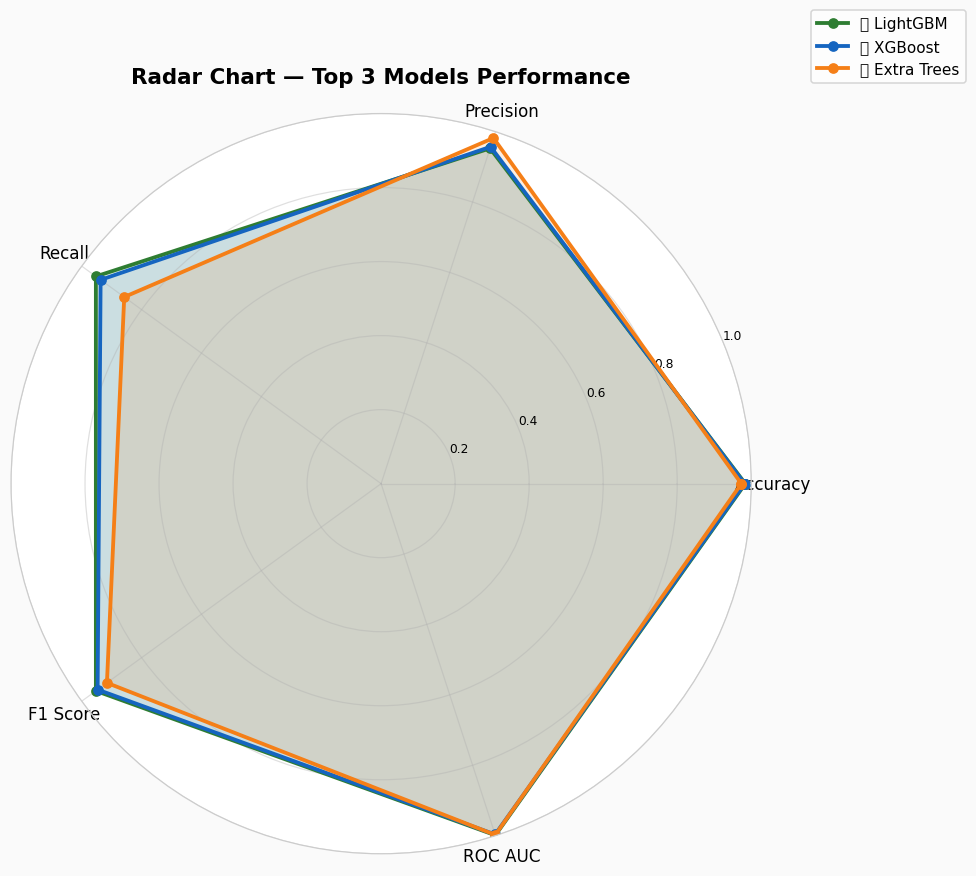

✅ Radar chart saved.


In [22]:
# ── Radar chart — Top 3 models ────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
n_metrics     = len(metrics_radar)
angles        = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles       += angles[:1]   # close the polygon

top3_colors   = [COLOR_SUCCESS, "#1565C0", COLOR_WARN]
top3_labels   = [f"🥇 {BEST_MODEL}", f"🥈 {SECOND_MODEL}", f"🥉 {THIRD_MODEL}"]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))

for name, color, label in zip(top3, top3_colors, top3_labels):
    values = df_results[df_results["Model"] == name][metrics_radar].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", color=color, lw=2.5, label=label, markersize=6)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.set_title("Radar Chart — Top 3 Models Performance",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=10)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("plots/radar_chart_top3.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Radar chart saved.")

In [23]:
# ── ROC AUC Ranking ───────────────────────────────────────────────────────────
df_roc_rank = df_results[["Model", "ROC AUC"]].sort_values("ROC AUC", ascending=False).reset_index(drop=True)
df_roc_rank.index += 1

# Accuracy Ranking
df_acc_rank = df_results[["Model", "Accuracy"]].sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_acc_rank.index += 1

# F1 Ranking
df_f1_rank = df_results[["Model", "F1 Score"]].sort_values("F1 Score", ascending=False).reset_index(drop=True)
df_f1_rank.index += 1

print("🏆 ROC AUC RANKING")
display(df_roc_rank.style.background_gradient(cmap="Greens").format({"ROC AUC": "{:.4f}"}))

print()
print("🏆 ACCURACY RANKING")
display(df_acc_rank.style.background_gradient(cmap="Blues").format({"Accuracy": "{:.4f}"}))

print()
print("🏆 F1 SCORE RANKING")
display(df_f1_rank.style.background_gradient(cmap="Oranges").format({"F1 Score": "{:.4f}"}))

🏆 ROC AUC RANKING


,Model,ROC AUC
1,LightGBM,0.9988
2,Extra Trees,0.9978
3,XGBoost,0.9967
4,Random Forest,0.9958
5,CatBoost,0.9905
6,Gradient Boosting,0.9567
7,Support Vector Machine,0.9414
8,AdaBoost,0.9084
9,K-Nearest Neighbors,0.9035
10,Decision Tree,0.9009



🏆 ACCURACY RANKING


,Model,Accuracy
1,LightGBM,0.9840
2,XGBoost,0.9822
3,Extra Trees,0.9734
4,Random Forest,0.9636
5,CatBoost,0.9512
6,Decision Tree,0.9503
7,Gradient Boosting,0.9281
8,AdaBoost,0.8890
9,K-Nearest Neighbors,0.8810
10,Support Vector Machine,0.8748



🏆 F1 SCORE RANKING


,Model,F1 Score
1,LightGBM,0.9526
2,XGBoost,0.9468
3,Extra Trees,0.9157
4,Random Forest,0.8818
5,CatBoost,0.8681
6,Decision Tree,0.8486
7,Gradient Boosting,0.7625
8,Support Vector Machine,0.7069
9,AdaBoost,0.6082
10,K-Nearest Neighbors,0.5563


## 🔧 Section 7 — Hyperparameter Tuning

Perform `RandomizedSearchCV` on the **Top 3** models identified in Section 6.

| Parameter | Value |
|-----------|-------|
| Method | RandomizedSearchCV |
| n_iter | 30 |
| cv | 5 (StratifiedKFold) |
| Scoring | ROC AUC |
| Random state | 42 |

---

In [24]:
# ── Hyperparameter search spaces ─────────────────────────────────────────────
PARAM_GRIDS = {
    "Logistic Regression": {
        "C"          : [0.001, 0.01, 0.1, 1, 10, 100],
        "solver"     : ["liblinear", "lbfgs", "saga"],
        "penalty"    : ["l1", "l2"],
        "max_iter"   : [500, 1000, 2000],
    },
    "Decision Tree": {
        "max_depth"         : [None, 3, 5, 7, 10, 15, 20],
        "min_samples_split" : [2, 5, 10, 20],
        "min_samples_leaf"  : [1, 2, 4, 8],
        "criterion"         : ["gini", "entropy"],
        "max_features"      : ["sqrt", "log2", None],
    },
    "Random Forest": {
        "n_estimators"      : [100, 200, 300, 500],
        "max_depth"         : [None, 5, 10, 15, 20],
        "min_samples_split" : [2, 5, 10],
        "min_samples_leaf"  : [1, 2, 4],
        "max_features"      : ["sqrt", "log2"],
    },
    "Extra Trees": {
        "n_estimators"      : [100, 200, 300],
        "max_depth"         : [None, 5, 10, 15, 20],
        "min_samples_split" : [2, 5, 10],
        "min_samples_leaf"  : [1, 2, 4],
        "max_features"      : ["sqrt", "log2"],
    },
    "AdaBoost": {
        "n_estimators"  : [50, 100, 200, 300],
        "learning_rate" : [0.01, 0.05, 0.1, 0.5, 1.0],
        "algorithm"     : ["SAMME"],
    },
    "Gradient Boosting": {
        "n_estimators"      : [100, 200, 300],
        "learning_rate"     : [0.01, 0.05, 0.1, 0.2],
        "max_depth"         : [3, 4, 5, 6, 8],
        "min_samples_split" : [2, 5, 10],
        "subsample"         : [0.7, 0.8, 0.9, 1.0],
    },
    "XGBoost": {
        "n_estimators"  : [100, 200, 300],
        "learning_rate" : [0.01, 0.05, 0.1, 0.2, 0.3],
        "max_depth"     : [3, 4, 5, 6, 8],
        "subsample"     : [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha"     : [0, 0.01, 0.1, 1],
        "reg_lambda"    : [0.5, 1, 2, 5],
    },
    "LightGBM": {
        "n_estimators"   : [100, 200, 300],
        "learning_rate"  : [0.01, 0.05, 0.1, 0.2],
        "max_depth"      : [-1, 5, 10, 15],
        "num_leaves"     : [20, 31, 50, 70, 100],
        "subsample"      : [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    },
    "CatBoost": {
        "iterations"     : [100, 200, 300],
        "learning_rate"  : [0.01, 0.05, 0.1, 0.2],
        "depth"          : [4, 6, 8, 10],
        "l2_leaf_reg"    : [1, 3, 5, 10],
    },
    "K-Nearest Neighbors": {
        "n_neighbors" : [3, 5, 7, 9, 11, 15, 21],
        "weights"     : ["uniform", "distance"],
        "metric"      : ["euclidean", "manhattan", "minkowski"],
        "p"           : [1, 2],
    },
    "Support Vector Machine": {
        "C"      : [0.1, 1, 5, 10, 50],
        "kernel" : ["rbf", "linear", "poly"],
        "gamma"  : ["scale", "auto", 0.001, 0.01, 0.1],
    },
    "Naive Bayes": {
        "var_smoothing" : np.logspace(-12, -5, 20).tolist(),
    },
}

print("✅ Hyperparameter search spaces defined for all 12 models.")
print(f"\nTop-3 models to tune: {top3}")

✅ Hyperparameter search spaces defined for all 12 models.

Top-3 models to tune: ['LightGBM', 'XGBoost', 'Extra Trees']


In [25]:
# ── Perform RandomizedSearchCV on Top 3 models ───────────────────────────────
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_models    = {}
tuning_results  = []

print("=" * 70)
print("  HYPERPARAMETER TUNING — TOP 3 MODELS")
print("=" * 70)

for rank, name in enumerate(top3, 1):
    medal = ["🥇", "🥈", "🥉"][rank-1]
    print(f"\n{medal}  Tuning Rank {rank}: {name}")
    print(f"   Search space size: {sum(len(v) if isinstance(v, list) else 1 for v in PARAM_GRIDS[name].items())} parameters")

    # Base estimator (same class, default params to allow grid search to override)
    base_estimator = MODEL_REGISTRY[name].__class__(**{
        k: v for k, v in MODEL_REGISTRY[name].get_params().items()
        if k in ["random_state", "n_jobs", "verbosity", "verbose",
                 "class_weight", "probability",
                 "eval_metric", "scale_pos_weight", "auto_class_weights"]
    })

    search = RandomizedSearchCV(
        estimator=base_estimator,
        param_distributions=PARAM_GRIDS.get(name, {}),
        n_iter=30,
        cv=cv_tuning,
        scoring="roc_auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        error_score="raise",
        refit=True,
    )

    try:
        t0 = time.time()
        search.fit(X_train, y_train)
        tune_time = time.time() - t0

        best_model = search.best_estimator_
        y_pred_tuned  = best_model.predict(X_test)
        y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

        tuning_result = {
            "Rank"              : rank,
            "Model"             : name,
            "Best Params"       : str(search.best_params_),
            "Best CV Score"     : round(search.best_score_, 4),
            "Tuned Accuracy"    : round(accuracy_score(y_test, y_pred_tuned), 4),
            "Tuned Precision"   : round(precision_score(y_test, y_pred_tuned, zero_division=0), 4),
            "Tuned Recall"      : round(recall_score(y_test, y_pred_tuned), 4),
            "Tuned F1 Score"    : round(f1_score(y_test, y_pred_tuned), 4),
            "Tuned ROC AUC"     : round(roc_auc_score(y_test, y_proba_tuned), 4),
            "Tuning Time (s)"   : round(tune_time, 2),
        }
        tuning_results.append(tuning_result)
        tuned_models[name] = best_model

        print(f"   ✅ Tuning complete in {tune_time:.1f}s")
        print(f"   Best CV Score   : {search.best_score_:.4f}")
        print(f"   Tuned ROC AUC   : {tuning_result['Tuned ROC AUC']:.4f}")
        print(f"   Tuned Accuracy  : {tuning_result['Tuned Accuracy']:.4f}")
        print(f"   Tuned F1 Score  : {tuning_result['Tuned F1 Score']:.4f}")
        print(f"   Best Params     : {search.best_params_}")

    except Exception as e:
        print(f"   ❌ Tuning failed: {e}")
        # Fall back to original trained model
        tuned_models[name] = trained_models[name]

print()
print("=" * 70)
print(f"  Tuning complete: {len(tuned_models)} models tuned.")
print("=" * 70)

  HYPERPARAMETER TUNING — TOP 3 MODELS

🥇  Tuning Rank 1: LightGBM
   Search space size: 6 parameters
   ✅ Tuning complete in 56.7s
   Best CV Score   : 0.9751
   Tuned ROC AUC   : 0.9989
   Tuned Accuracy  : 0.9920
   Tuned F1 Score  : 0.9759
   Best Params     : {'subsample': 0.6, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.9}

🥈  Tuning Rank 2: XGBoost
   Search space size: 7 parameters
   ✅ Tuning complete in 44.2s
   Best CV Score   : 0.9713
   Tuned ROC AUC   : 0.9971
   Tuned Accuracy  : 0.9831
   Tuned F1 Score  : 0.9493
   Best Params     : {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 0.9}

🥉  Tuning Rank 3: Extra Trees
   Search space size: 5 parameters
   ✅ Tuning complete in 113.7s
   Best CV Score   : 0.9736
   Tuned ROC AUC   : 0.9956
   Tuned Accuracy  : 0.9742
   Tuned F1 Score  : 0.9197
   Best Params     : {'n_estimators': 300

In [26]:
# ── Tuning results table ─────────────────────────────────────────────────────
df_tuning = pd.DataFrame(tuning_results)

print("\n📊 HYPERPARAMETER TUNING RESULTS")
print("=" * 70)
display(df_tuning[[
    "Rank", "Model",
    "Best CV Score",
    "Tuned Accuracy", "Tuned Precision", "Tuned Recall",
    "Tuned F1 Score", "Tuned ROC AUC",
    "Tuning Time (s)"
]].style
    .background_gradient(subset=[
        "Best CV Score", "Tuned Accuracy", "Tuned F1 Score", "Tuned ROC AUC"
    ], cmap="Greens")
    .format({
        "Best CV Score"   : "{:.4f}",
        "Tuned Accuracy"  : "{:.4f}",
        "Tuned Precision" : "{:.4f}",
        "Tuned Recall"    : "{:.4f}",
        "Tuned F1 Score"  : "{:.4f}",
        "Tuned ROC AUC"   : "{:.4f}",
        "Tuning Time (s)" : "{:.2f}",
    })
    .set_caption("RandomizedSearchCV Results — Top 3 Models")
)


📊 HYPERPARAMETER TUNING RESULTS


,Rank,Model,Best CV Score,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1 Score,Tuned ROC AUC,Tuning Time (s)
0,1,LightGBM,0.9751,0.9920,0.9945,0.9579,0.9759,0.9989,56.73
1,2,XGBoost,0.9713,0.9831,0.9622,0.9368,0.9493,0.9971,44.21
2,3,Extra Trees,0.9736,0.9742,0.9708,0.8737,0.9197,0.9956,113.68


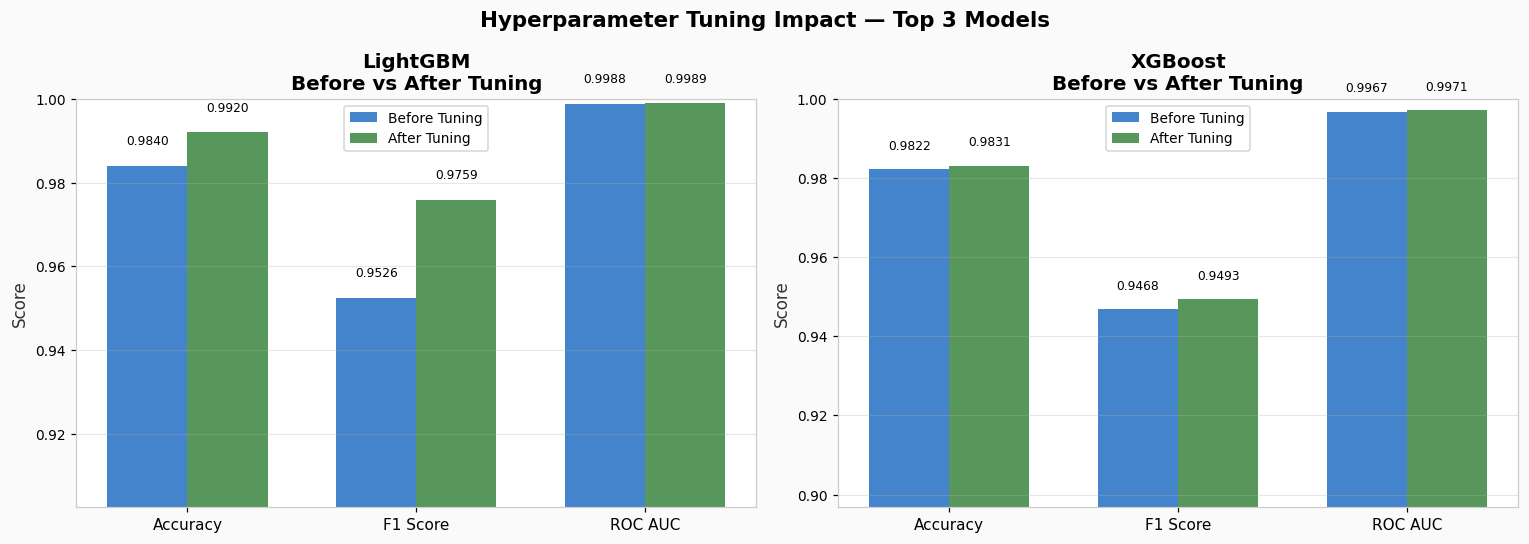

✅ Tuning impact chart saved.


In [27]:
# ── Before vs After Tuning comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_compare = ["Accuracy", "F1 Score", "ROC AUC"]
width = 0.35
x = np.arange(len(metrics_compare))

for ax_idx, (name, tuned_row) in enumerate(zip(top3, tuning_results)):
    if ax_idx >= 2: break
    ax = axes[ax_idx]

    # Before values (from df_results)
    before_row = df_results[df_results["Model"] == name].iloc[0]
    before_vals = [before_row[m] for m in metrics_compare]
    after_vals  = [tuned_row[f"Tuned {m}"] for m in metrics_compare]

    bars1 = ax.bar(x - width/2, before_vals, width, label="Before Tuning",
                   color=COLOR_PRIMARY, alpha=0.8)
    bars2 = ax.bar(x + width/2, after_vals,  width, label="After Tuning",
                   color=COLOR_SUCCESS, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_compare, fontsize=10)
    ax.set_ylabel("Score")
    ax.set_title(f"{name}\nBefore vs After Tuning", fontweight="bold")
    ax.set_ylim([min(before_vals + after_vals) - 0.05, 1.0])
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{bar.get_height():.4f}", ha="center", fontsize=8)

plt.suptitle("Hyperparameter Tuning Impact — Top 3 Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/hyperparameter_tuning_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tuning impact chart saved.")

## 🌿 Section 8 — Feature Importance

Extract feature importance from all tree-based models.

**Tree-based models with feature importance:**
- Decision Tree, Random Forest, Extra Trees
- AdaBoost, Gradient Boosting
- XGBoost, LightGBM, CatBoost

---

In [28]:
# ── Feature importance extraction ────────────────────────────────────────────
feature_names = list(X_train.columns)

TREE_MODELS = [
    "Decision Tree", "Random Forest", "Extra Trees",
    "AdaBoost", "Gradient Boosting",
    "XGBoost", "LightGBM", "CatBoost"
]

fi_data = {}   # name -> pd.Series(importance, index=feature_names)

for name in TREE_MODELS:
    model = trained_models.get(name)
    if model is None:
        continue
    try:
        importances = model.feature_importances_
        fi_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        fi_data[name] = fi_series
        print(f"  ✅ {name:<28s}  top feature: {fi_series.idxmax()} ({fi_series.max():.4f})")
    except AttributeError:
        print(f"  ⚠️  {name} — no feature_importances_ attribute")

print(f"\n✅ Feature importance extracted from {len(fi_data)} tree-based models.")

  ✅ Decision Tree                 top feature: Tenure (0.3428)
  ✅ Random Forest                 top feature: Tenure (0.2263)
  ✅ Extra Trees                   top feature: Tenure (0.1453)
  ✅ AdaBoost                      top feature: Tenure (0.3190)
  ✅ Gradient Boosting             top feature: Tenure (0.3970)
  ✅ XGBoost                       top feature: Tenure (0.1943)
  ✅ LightGBM                      top feature: ComplaintRiskScore (617.0000)
  ✅ CatBoost                      top feature: Tenure (18.6974)

✅ Feature importance extracted from 8 tree-based models.


In [29]:
# ── Average feature importance across all tree models ─────────────────────────
fi_df = pd.DataFrame(fi_data).fillna(0)
fi_df["Average Importance"] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values("Average Importance", ascending=False)

print("\n📊 FEATURE IMPORTANCE TABLE (Average across all tree models)")
print("=" * 70)
display(fi_df.style.background_gradient(subset=["Average Importance"], cmap="YlOrRd")
    .format("{:.6f}")
    .set_caption("Feature Importance — Average Across All Tree-Based Models")
)

# Save to CSV
fi_df.reset_index().rename(columns={"index": "Feature"}).to_csv(
    "feature_importance.csv", index=False
)
print("\n✅ feature_importance.csv saved.")


📊 FEATURE IMPORTANCE TABLE (Average across all tree models)


,Decision Tree,Random Forest,Extra Trees,AdaBoost,Gradient Boosting,XGBoost,LightGBM,CatBoost,Average Importance
ComplaintRiskScore,0.074298,0.064740,0.049564,0.022585,0.039044,0.034666,617.000000,5.408978,77.836734
CashbackAmount,0.090576,0.071832,0.039578,0.051955,0.071284,0.036430,503.000000,5.368783,63.591305
Tenure,0.342820,0.226339,0.145322,0.319007,0.397017,0.194302,448.000000,18.697355,58.540270
AverageOrderBehaviorScore,0.028290,0.044041,0.029234,0.000000,0.024020,0.016938,463.000000,2.602353,58.218110
WarehouseToHome,0.037628,0.038853,0.035783,0.018454,0.034396,0.025266,406.000000,5.041318,51.403962
LoyaltyScore,0.036654,0.080615,0.057395,0.076020,0.022715,0.029102,357.000000,6.423977,45.465810
CustomerValueScore,0.034008,0.038076,0.024905,0.000000,0.015510,0.015568,306.000000,2.275030,38.550387
OrderAmountHikeFromlastYear,0.029391,0.027567,0.032180,0.011479,0.009450,0.021781,303.000000,2.313839,38.180711
NumberOfAddress,0.051016,0.032818,0.038391,0.043353,0.062505,0.036947,292.000000,6.686011,37.368880
OrderEngagementScore,0.033503,0.039034,0.034775,0.048613,0.029279,0.033993,266.000000,2.646600,33.608225



✅ feature_importance.csv saved.


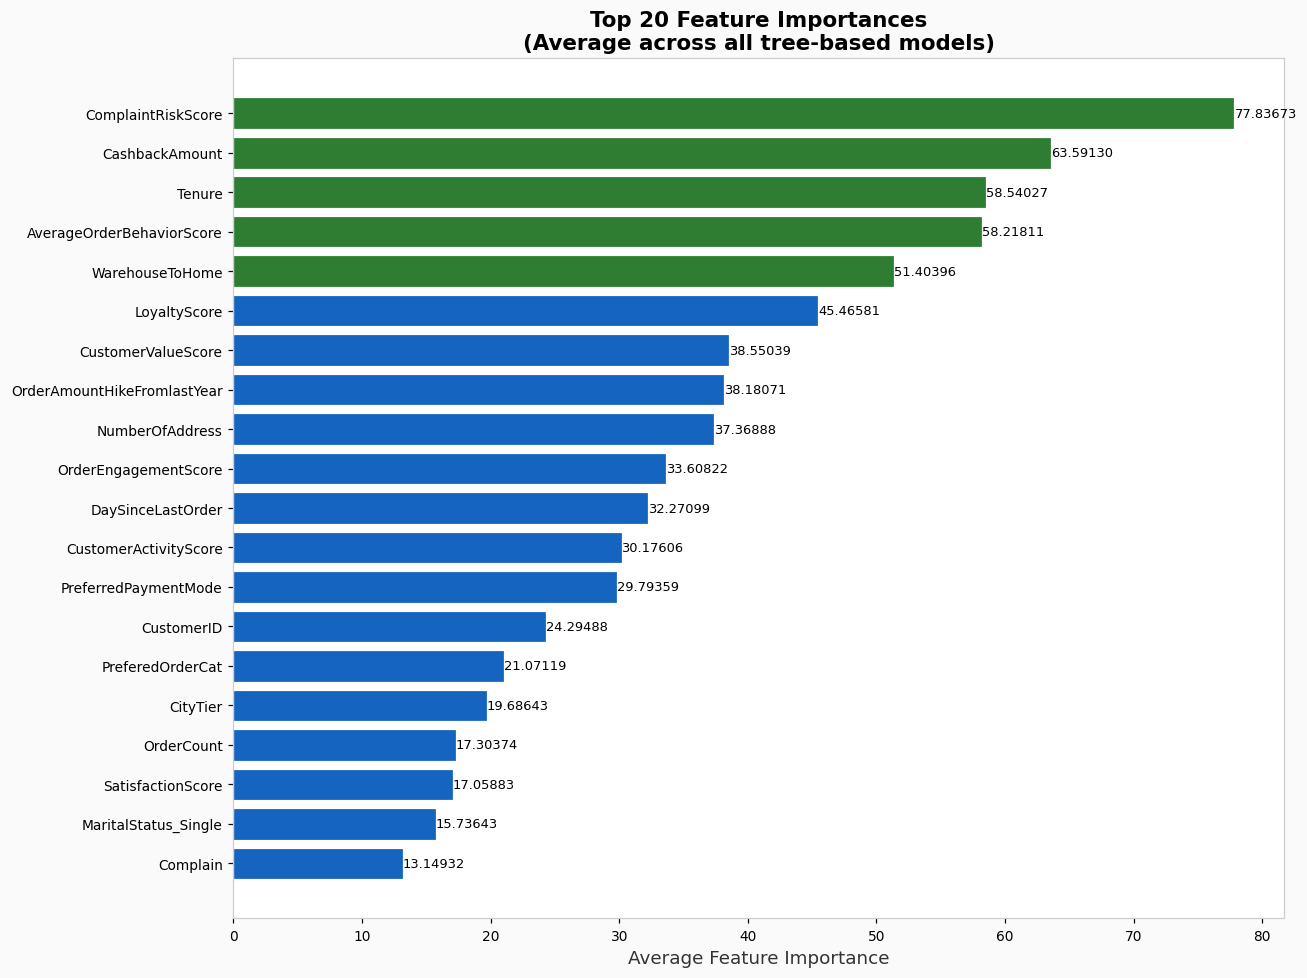

✅ Average feature importance chart saved.


In [30]:
# ── Top-20 Average Feature Importance — Horizontal Bar Chart ─────────────────
top_n   = min(20, len(fi_df))
top_fi  = fi_df["Average Importance"].head(top_n).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors_fi = [COLOR_SUCCESS if i >= top_n - 5 else COLOR_PRIMARY
             for i in range(top_n)]
bars = ax.barh(top_fi.index, top_fi.values, color=colors_fi,
               edgecolor="white", linewidth=0.8)
ax.set_xlabel("Average Feature Importance", fontsize=12)
ax.set_title(f"Top {top_n} Feature Importances\n(Average across all tree-based models)",
             fontsize=14, fontweight="bold")

for bar, val in zip(bars, top_fi.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va="center", fontsize=8.5)

plt.tight_layout()
plt.savefig("plots/feature_importance_avg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Average feature importance chart saved.")

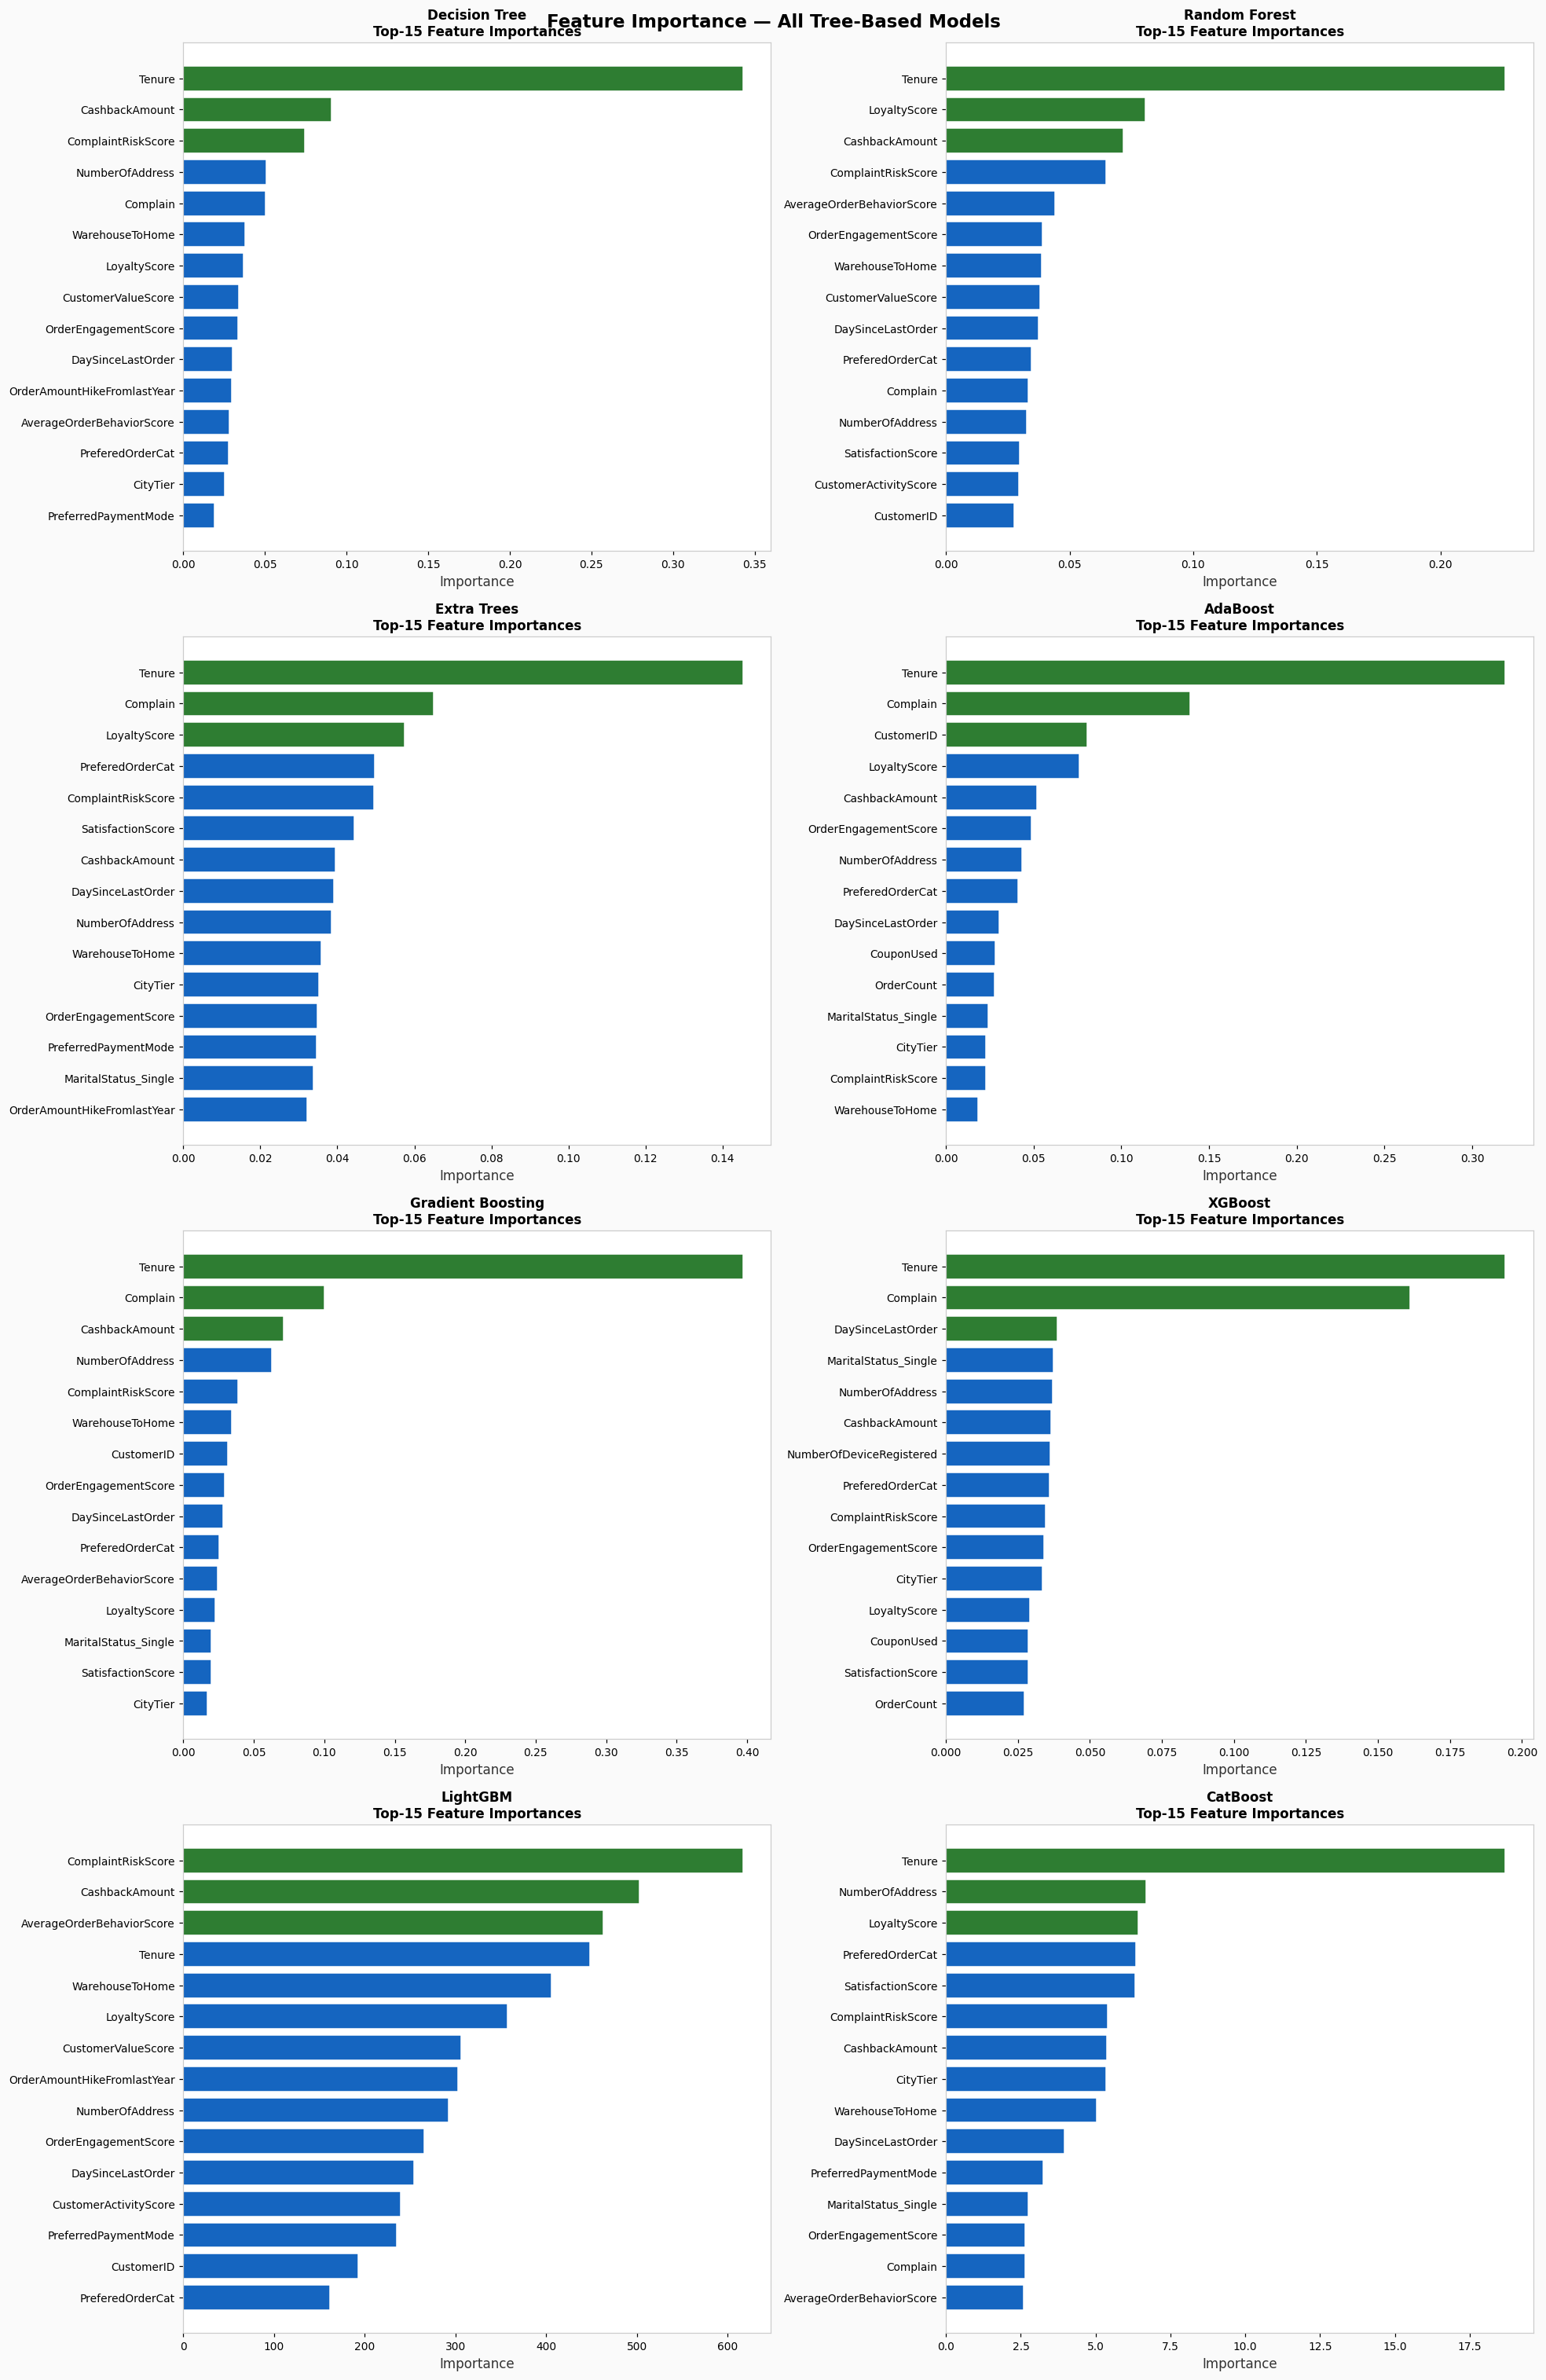

✅ Per-model feature importance plots saved.


In [31]:
# ── Per-model feature importance plots (top-15 features each) ────────────────
n_models_fi = len(fi_data)
n_cols_fi   = 2
n_rows_fi   = -(-n_models_fi // n_cols_fi)

fig, axes = plt.subplots(n_rows_fi, n_cols_fi, figsize=(18, n_rows_fi * 7))
axes = axes.flatten()

for i, (name, fi_series) in enumerate(fi_data.items()):
    top15 = fi_series.head(15).sort_values(ascending=True)
    color = [COLOR_SUCCESS if j >= len(top15) - 3 else COLOR_PRIMARY
             for j in range(len(top15))]
    axes[i].barh(top15.index, top15.values, color=color, edgecolor="white")
    axes[i].set_title(f"{name}\nTop-15 Feature Importances", fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Importance")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Importance — All Tree-Based Models", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/feature_importance_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Per-model feature importance plots saved.")

## 🔍 Section 9 — SHAP Explainability

Run SHAP analysis on the **best tuned model** to understand *how* each feature
influences the churn prediction at the individual and global level.

**SHAP Plots Generated:**
1. **Summary Plot** — Feature impact distribution (beeswarm)
2. **Bar Plot** — Mean absolute SHAP values (global feature importance)

---

In [32]:
# ── Select the best tuned model for SHAP ─────────────────────────────────────
best_tuned_model_name = top3[0]   # highest ranked model
best_tuned_model      = tuned_models.get(best_tuned_model_name,
                                         trained_models[best_tuned_model_name])

print(f"✅ Running SHAP on best model: {best_tuned_model_name}")
print(f"   Model type: {type(best_tuned_model).__name__}")

# Select background sample for SHAP (use at most 500 rows for speed)
X_shap_bg   = shap.sample(X_train, min(500, len(X_train)), random_state=RANDOM_STATE)
X_shap_test = X_test.copy()

# Choose explainer based on model type
TREE_BASED = [
    "RandomForestClassifier", "ExtraTreesClassifier",
    "GradientBoostingClassifier", "AdaBoostClassifier",
    "DecisionTreeClassifier",
    "XGBClassifier", "LGBMClassifier", "CatBoostClassifier"
]

model_class = type(best_tuned_model).__name__

try:
    if model_class in TREE_BASED:
        explainer = shap.TreeExplainer(best_tuned_model)
        shap_values = explainer.shap_values(X_shap_test)
        # For multi-output (binary), take class 1 values
        if isinstance(shap_values, list) and len(shap_values) == 2:
            shap_values_plot = shap_values[1]
        else:
            shap_values_plot = shap_values
    else:
        explainer = shap.KernelExplainer(
            best_tuned_model.predict_proba,
            X_shap_bg
        )
        shap_values_obj = explainer.shap_values(X_shap_test.iloc[:200])
        if isinstance(shap_values_obj, list) and len(shap_values_obj) == 2:
            shap_values_plot = shap_values_obj[1]
        else:
            shap_values_plot = shap_values_obj
        X_shap_test = X_shap_test.iloc[:200]

    print(f"✅ SHAP values computed. Shape: {np.array(shap_values_plot).shape}")
except Exception as e:
    print(f"⚠️  SHAP computation error: {e}")
    print("    Falling back to KernelExplainer with random forest...")
    backup_model = trained_models.get("Random Forest", trained_models[top3[0]])
    explainer = shap.TreeExplainer(backup_model)
    shap_values = explainer.shap_values(X_shap_test)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    best_tuned_model_name = "Random Forest (Fallback)"
    print(f"✅ SHAP fallback successful.")

✅ Running SHAP on best model: LightGBM
   Model type: LGBMClassifier
✅ SHAP values computed. Shape: (1126, 27)


Generating SHAP Summary Plot for: LightGBM


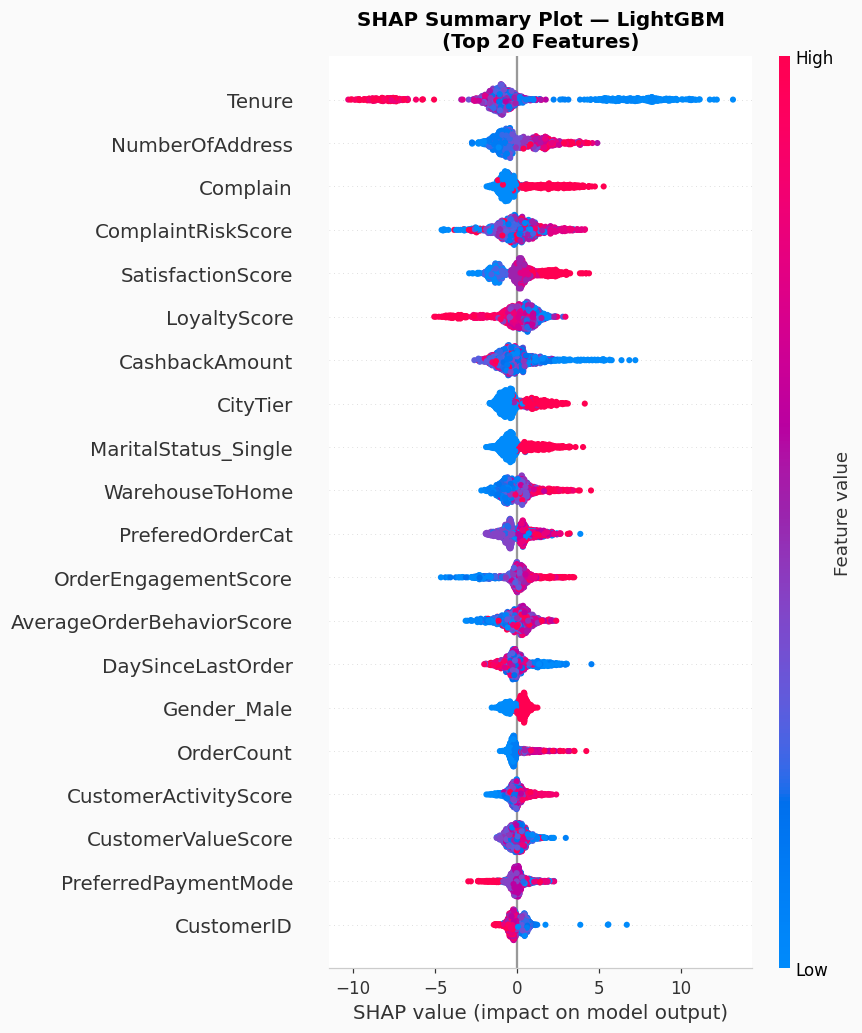

✅ SHAP summary plot (beeswarm) saved.


In [33]:
# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────────
print(f"Generating SHAP Summary Plot for: {best_tuned_model_name}")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_plot,
    X_shap_test,
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title(f"SHAP Summary Plot — {best_tuned_model_name}\n(Top 20 Features)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP summary plot (beeswarm) saved.")

Generating SHAP Bar Plot for: LightGBM


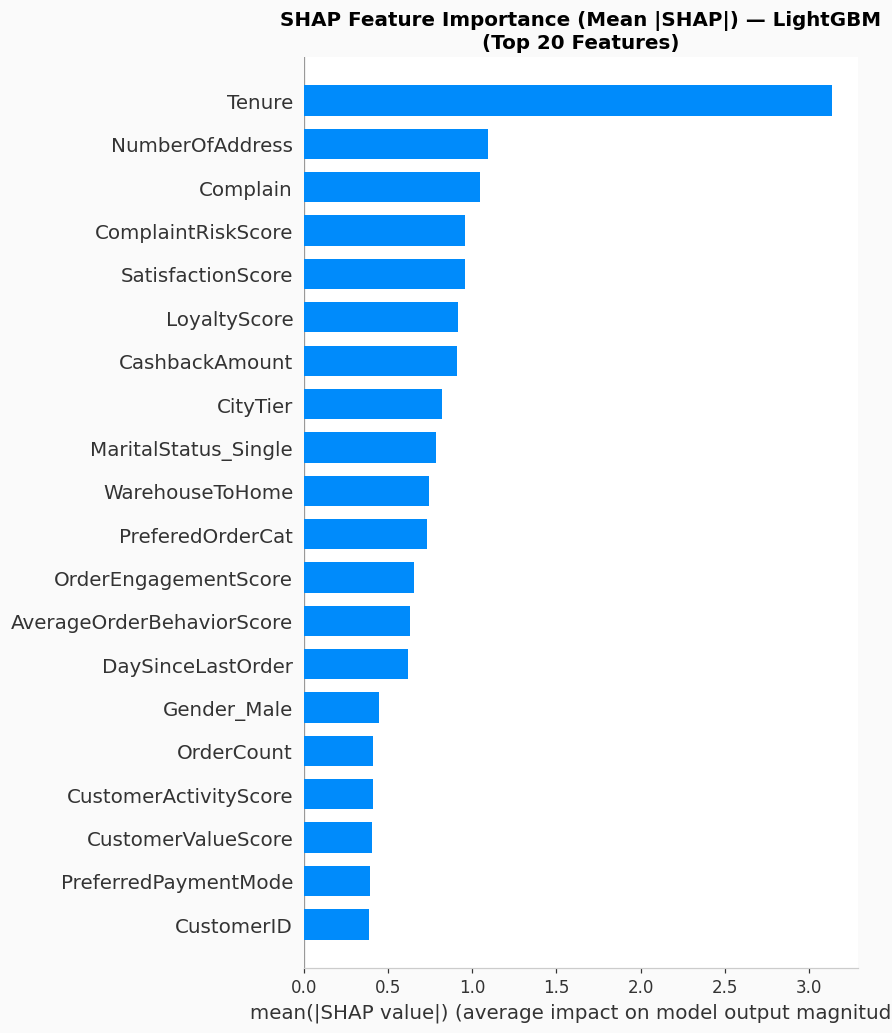

✅ SHAP bar plot (mean absolute SHAP) saved.


In [34]:
# ── SHAP Bar Plot (Mean |SHAP|) ───────────────────────────────────────────────
print(f"Generating SHAP Bar Plot for: {best_tuned_model_name}")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_plot,
    X_shap_test,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title(f"SHAP Feature Importance (Mean |SHAP|) — {best_tuned_model_name}\n(Top 20 Features)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/shap_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP bar plot (mean absolute SHAP) saved.")

In [35]:
# ── SHAP Feature Importance Table ─────────────────────────────────────────────
shap_importance = pd.DataFrame({
    "Feature"              : feature_names,
    "Mean |SHAP Value|"    : np.abs(shap_values_plot).mean(axis=0),
}).sort_values("Mean |SHAP Value|", ascending=False).reset_index(drop=True)
shap_importance.index += 1

print(f"\n📊 SHAP Feature Importance — {best_tuned_model_name}")
display(shap_importance.head(20).style
    .background_gradient(subset=["Mean |SHAP Value|"], cmap="Reds")
    .format({"Mean |SHAP Value|": "{:.6f}"})
    .set_caption(f"Top 20 Features by Mean |SHAP| Value — {best_tuned_model_name}")
)


📊 SHAP Feature Importance — LightGBM


,Feature,Mean |SHAP Value|
1,Tenure,3.134532
2,NumberOfAddress,1.091706
3,Complain,1.046537
4,ComplaintRiskScore,0.957209
5,SatisfactionScore,0.954835
6,LoyaltyScore,0.917782
7,CashbackAmount,0.912453
8,CityTier,0.822744
9,MaritalStatus_Single,0.784213
10,WarehouseToHome,0.742922


## 💾 Section 10 — Save All Models

Save every trained model individually to the `models/` directory.

**Files saved:**
- `logistic_regression.pkl`, `decision_tree.pkl`, `random_forest.pkl`
- `extra_trees.pkl`, `adaboost.pkl`, `gradient_boosting.pkl`
- `xgboost.pkl`, `lightgbm.pkl`, `catboost.pkl`
- `knn.pkl`, `svm.pkl`, `naive_bayes.pkl`
- `tuned_model_1.pkl`, `tuned_model_2.pkl`, `tuned_model_3.pkl`

---

In [36]:
# ── Save all 12 trained models ───────────────────────────────────────────────
print("Saving all 12 trained models...")
print("=" * 55)

save_status = []

for name, filepath in MODEL_FILENAMES.items():
    model = trained_models.get(name)
    if model is not None:
        try:
            joblib.dump(model, filepath)
            size_kb = os.path.getsize(filepath) / 1024
            save_status.append({"Model": name, "File": filepath, "Size (KB)": round(size_kb, 1), "Status": "✅ Saved"})
            print(f"  ✅  {name:<28s}  →  {filepath:<38s}  {size_kb:.1f} KB")
        except Exception as e:
            save_status.append({"Model": name, "File": filepath, "Size (KB)": 0, "Status": f"❌ {e}"})
            print(f"  ❌  {name:<28s}  →  FAILED: {e}")
    else:
        save_status.append({"Model": name, "File": filepath, "Size (KB)": 0, "Status": "⚠️  Not trained"})
        print(f"  ⚠️  {name:<28s}  →  Not trained")

print()
print(f"  {len([s for s in save_status if '✅' in s['Status']])}/{len(save_status)} models saved successfully.")

Saving all 12 trained models...
  ✅  Logistic Regression           →  models/logistic_regression.pkl          1.8 KB
  ✅  Decision Tree                 →  models/decision_tree.pkl                59.9 KB
  ✅  Random Forest                 →  models/random_forest.pkl                12938.0 KB
  ✅  Extra Trees                   →  models/extra_trees.pkl                  29146.9 KB
  ✅  AdaBoost                      →  models/adaboost.pkl                     64.7 KB
  ✅  Gradient Boosting             →  models/gradient_boosting.pkl            266.1 KB
  ✅  XGBoost                       →  models/xgboost.pkl                      473.1 KB
  ✅  LightGBM                      →  models/lightgbm.pkl                     681.3 KB
  ✅  CatBoost                      →  models/catboost.pkl                     227.3 KB
  ✅  K-Nearest Neighbors           →  models/knn.pkl                          986.8 KB
  ✅  Support Vector Machine        →  models/svm.pkl                          484.1 KB
  ✅  Naive 

In [37]:
# ── Save Top-3 tuned models ──────────────────────────────────────────────────
print("\nSaving tuned models...")
print("=" * 55)

tuned_filepaths = {
    1: "models/tuned_model_1.pkl",
    2: "models/tuned_model_2.pkl",
    3: "models/tuned_model_3.pkl",
}

for rank, name in enumerate(top3, 1):
    fpath  = tuned_filepaths[rank]
    model  = tuned_models.get(name)
    if model is not None:
        try:
            joblib.dump(model, fpath)
            size_kb = os.path.getsize(fpath) / 1024
            print(f"  ✅  Rank {rank}: {name:<28s}  →  {fpath}  ({size_kb:.1f} KB)")
        except Exception as e:
            print(f"  ❌  Rank {rank}: {name}  →  FAILED: {e}")
    else:
        print(f"  ⚠️  Rank {rank}: {name}  →  No tuned model available")

print()
print("✅ All model files saved.")


Saving tuned models...
  ✅  Rank 1: LightGBM                      →  models/tuned_model_1.pkl  (1042.9 KB)
  ✅  Rank 2: XGBoost                       →  models/tuned_model_2.pkl  (523.6 KB)
  ✅  Rank 3: Extra Trees                   →  models/tuned_model_3.pkl  (33240.9 KB)

✅ All model files saved.


In [38]:
# ── Complete model inventory ──────────────────────────────────────────────────
print("\n📦 COMPLETE MODEL INVENTORY")
print("=" * 65)
print(f"  {'File':<45s}  {'Size':>8s}  Status")
print("  " + "-" * 62)

total_size = 0
for fpath in sorted([
    *MODEL_FILENAMES.values(),
    *tuned_filepaths.values(),
]):
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        total_size += size_kb
        print(f"  {fpath:<45s}  {size_kb:>6.1f} KB  ✅")
    else:
        print(f"  {fpath:<45s}  {'---':>8s}  ❌ Missing")

print()
print(f"  Total models saved : 15 (12 base + 3 tuned)")
print(f"  Total size         : {total_size:.1f} KB  ({total_size/1024:.2f} MB)")


📦 COMPLETE MODEL INVENTORY
  File                                               Size  Status
  --------------------------------------------------------------
  models/adaboost.pkl                              64.7 KB  ✅
  models/catboost.pkl                             227.3 KB  ✅
  models/decision_tree.pkl                         59.9 KB  ✅
  models/extra_trees.pkl                         29146.9 KB  ✅
  models/gradient_boosting.pkl                    266.1 KB  ✅
  models/knn.pkl                                  986.8 KB  ✅
  models/lightgbm.pkl                             681.3 KB  ✅
  models/logistic_regression.pkl                    1.8 KB  ✅
  models/naive_bayes.pkl                            2.4 KB  ✅
  models/random_forest.pkl                       12938.0 KB  ✅
  models/svm.pkl                                  484.1 KB  ✅
  models/tuned_model_1.pkl                       1042.9 KB  ✅
  models/tuned_model_2.pkl                        523.6 KB  ✅
  models/tuned_model_3.pkl       

## 🏆 Section 10B — Best Model Detailed Analysis

Deep-dive into the best model's performance.

---

In [39]:
# ── Best model deep analysis ─────────────────────────────────────────────────
best_model_fitted = tuned_models.get(BEST_MODEL, trained_models[BEST_MODEL])
y_pred_best       = best_model_fitted.predict(X_test)
y_proba_best      = best_model_fitted.predict_proba(X_test)[:, 1]

best_metrics = {
    "Model"     : [BEST_MODEL],
    "Accuracy"  : [round(accuracy_score(y_test, y_pred_best), 4)],
    "Precision" : [round(precision_score(y_test, y_pred_best, zero_division=0), 4)],
    "Recall"    : [round(recall_score(y_test, y_pred_best), 4)],
    "F1 Score"  : [round(f1_score(y_test, y_pred_best), 4)],
    "ROC AUC"   : [round(roc_auc_score(y_test, y_proba_best), 4)],
}

df_best = pd.DataFrame(best_metrics)
df_best.to_csv("best_model_metrics.csv", index=False)

print(f"🏆 BEST MODEL: {BEST_MODEL}")
print("=" * 55)
print(f"  Accuracy  : {best_metrics['Accuracy'][0]:.4f}")
print(f"  Precision : {best_metrics['Precision'][0]:.4f}")
print(f"  Recall    : {best_metrics['Recall'][0]:.4f}")
print(f"  F1 Score  : {best_metrics['F1 Score'][0]:.4f}")
print(f"  ROC AUC   : {best_metrics['ROC AUC'][0]:.4f}")
print()
print(f"  Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=["Retained (0)", "Churned (1)"]))

print("\n✅ best_model_metrics.csv saved.")

🏆 BEST MODEL: LightGBM
  Accuracy  : 0.9920
  Precision : 0.9945
  Recall    : 0.9579
  F1 Score  : 0.9759
  ROC AUC   : 0.9989

  Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.99      1.00      1.00       936
 Churned (1)       0.99      0.96      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.99      1126
weighted avg       0.99      0.99      0.99      1126


✅ best_model_metrics.csv saved.


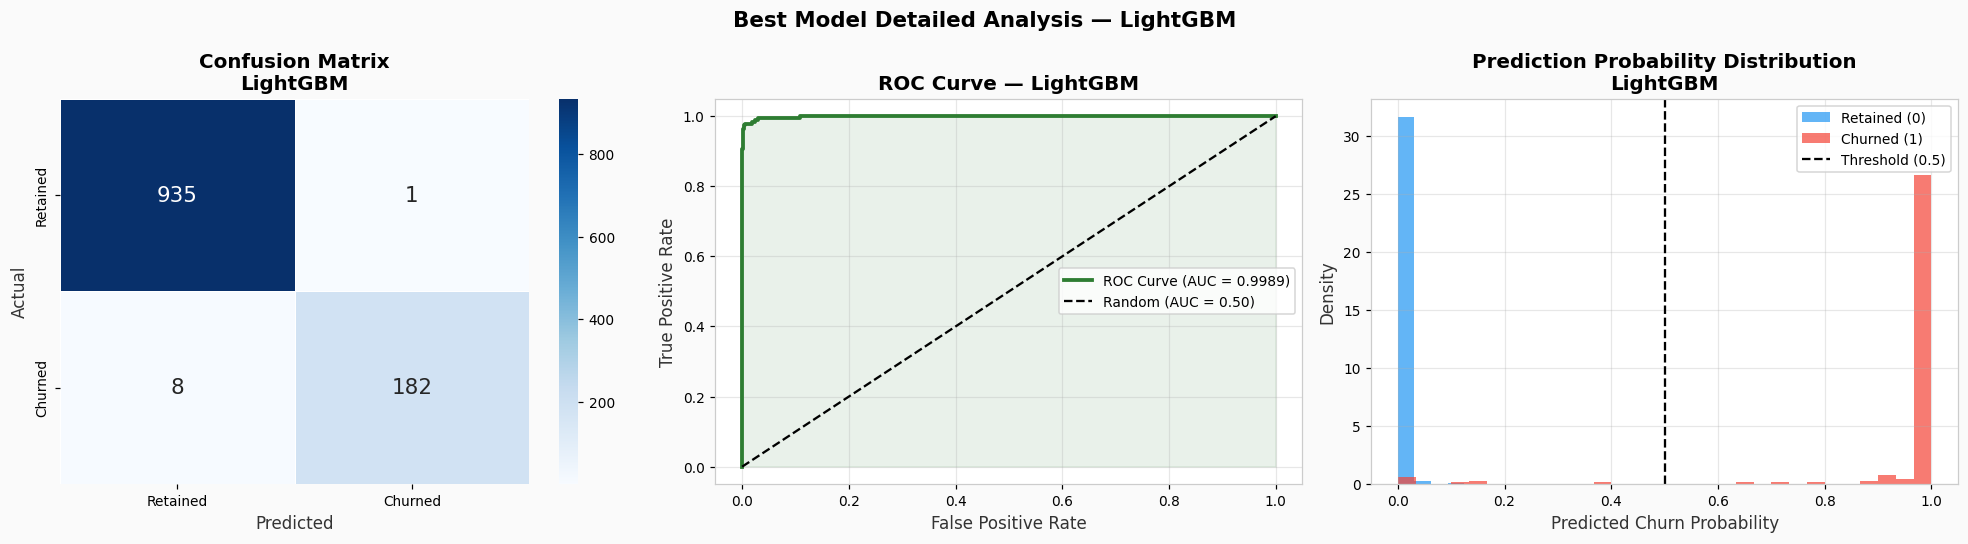

✅ Best model detailed analysis chart saved.


In [40]:
# ── Best model — Detailed visual report ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Retained", "Churned"],
            yticklabels=["Retained", "Churned"],
            ax=axes[0], linewidths=0.5, annot_kws={"size": 14})
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].set_title(f"Confusion Matrix\n{BEST_MODEL}", fontweight="bold")

# 2. ROC Curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_best)
roc_auc_b        = auc(fpr_b, tpr_b)
axes[1].plot(fpr_b, tpr_b, color=COLOR_SUCCESS, lw=2.5,
             label=f"ROC Curve (AUC = {roc_auc_b:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")
axes[1].fill_between(fpr_b, tpr_b, alpha=0.1, color=COLOR_SUCCESS)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve — {BEST_MODEL}", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# 3. Prediction Probability Distribution
axes[2].hist(y_proba_best[y_test == 0], bins=30, alpha=0.7,
             color=PALETTE_CHURN[0], label="Retained (0)", density=True)
axes[2].hist(y_proba_best[y_test == 1], bins=30, alpha=0.7,
             color=PALETTE_CHURN[1], label="Churned (1)", density=True)
axes[2].axvline(0.5, color="black", linestyle="--", lw=1.5, label="Threshold (0.5)")
axes[2].set_xlabel("Predicted Churn Probability")
axes[2].set_ylabel("Density")
axes[2].set_title(f"Prediction Probability Distribution\n{BEST_MODEL}", fontweight="bold")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f"Best Model Detailed Analysis — {BEST_MODEL}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/best_model_detailed_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Best model detailed analysis chart saved.")

## 📤 Section 10C — Final CSV Outputs

Save all report CSVs and verify their existence.

---

In [41]:
# ── Verify and display all final output files ────────────────────────────────
final_outputs = {
    "model_comparison.csv"       : "Full model comparison table",
    "cross_validation_results.csv": "5-fold CV results",
    "feature_importance.csv"     : "Feature importance (avg across tree models)",
    "best_model_metrics.csv"     : "Best model metrics summary",
}

print("📁 FINAL CSV OUTPUTS")
print("=" * 65)

for fpath, description in final_outputs.items():
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        df_tmp  = pd.read_csv(fpath)
        print(f"  ✅  {fpath:<35s}  {size_kb:>5.1f} KB  {df_tmp.shape[0]} rows × {df_tmp.shape[1]} cols")
        print(f"       → {description}")
    else:
        print(f"  ❌  {fpath:<35s}  NOT FOUND")

print()
print("📁 SAVED PLOTS")
print("=" * 65)
plot_files = sorted(os.listdir("plots")) if os.path.exists("plots") else []
for pf in plot_files:
    size_kb = os.path.getsize(f"plots/{pf}") / 1024
    print(f"  🖼️   plots/{pf:<45s}  {size_kb:.1f} KB")

📁 FINAL CSV OUTPUTS
  ✅  model_comparison.csv                   0.9 KB  12 rows × 13 cols
       → Full model comparison table
  ✅  cross_validation_results.csv           0.8 KB  12 rows × 8 cols
       → 5-fold CV results
  ✅  feature_importance.csv                 4.5 KB  27 rows × 10 cols
       → Feature importance (avg across tree models)
  ✅  best_model_metrics.csv                 0.1 KB  1 rows × 6 cols
       → Best model metrics summary

📁 SAVED PLOTS
  🖼️   plots/best_model_detailed_analysis.png               124.9 KB
  🖼️   plots/class_distribution.png                         59.9 KB
  🖼️   plots/confusion_matrices_all.png                     255.5 KB
  🖼️   plots/cross_validation_results.png                   161.6 KB
  🖼️   plots/feature_importance_avg.png                     155.1 KB
  🖼️   plots/feature_importance_per_model.png               517.5 KB
  🖼️   plots/hyperparameter_tuning_impact.png               74.5 KB
  🖼️   plots/model_comparison_metrics.png             

## ⬇️ Section 10D — Download Outputs (Google Colab)

Download all generated files to your local machine.

---

In [42]:
# ── Google Colab download helper ─────────────────────────────────────────────
try:
    from google.colab import files

    download_queue = []

    # CSVs
    for fname in ["model_comparison.csv", "cross_validation_results.csv",
                  "feature_importance.csv", "best_model_metrics.csv"]:
        if os.path.exists(fname):
            download_queue.append(fname)

    # Models
    for fname in list(MODEL_FILENAMES.values()) + [
        "models/tuned_model_1.pkl",
        "models/tuned_model_2.pkl",
        "models/tuned_model_3.pkl",
    ]:
        if os.path.exists(fname):
            download_queue.append(fname)

    print(f"Downloading {len(download_queue)} files...")
    for fpath in download_queue:
        files.download(fpath)
        print(f"  ⬇️  {fpath}")
    print("✅ All downloads triggered.")

except ImportError:
    print("ℹ️  Not running in Google Colab.")
    print("   All artefacts are available in the current working directory:")
    for fpath in ["model_comparison.csv", "cross_validation_results.csv",
                  "feature_importance.csv", "best_model_metrics.csv"]:
        if os.path.exists(fpath):
            print(f"   📄  {os.path.abspath(fpath)}")
    print("   📂  models/ — all trained model .pkl files")
    print("   📂  plots/  — all visualisation plots")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  models/tuned_model_2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  models/tuned_model_3.pkl
✅ All downloads triggered.


## 📑 Section 11 — Final Report

Comprehensive model performance ranking, business interpretation, and deployment recommendation.

---

In [43]:
# ── Final comprehensive report ───────────────────────────────────────────────
print("=" * 72)
print("  E-COMMERCE CUSTOMER CHURN — MODEL TRAINING & COMPARISON REPORT")
print("=" * 72)

# ─── 1. DATASET & SPLIT SUMMARY ─────────────────────────────────────────────
print()
print("── 1. DATASET & SPLIT SUMMARY ──────────────────────────────────────────")
print(f"   Total samples        : {len(df):,}")
print(f"   Training set         : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Test set             : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"   Features             : {X_train.shape[1]}")
print(f"   Target               : Churn (0=Retained, 1=Churned)")
print(f"   Churn rate (train)   : {y_train.mean()*100:.2f}%")
print(f"   Churn rate (test)    : {y_test.mean()*100:.2f}%")

# ─── 2. MODEL PERFORMANCE RANKING ────────────────────────────────────────────
print()
print("── 2. MODEL PERFORMANCE RANKING (by ROC AUC) ──────────────────────────")
print(f"   {'Rank':<5}  {'Model':<30}  {'Accuracy':>9}  {'F1 Score':>9}  {'ROC AUC':>9}")
print("   " + "-" * 65)

df_rank_print = df_results.sort_values("ROC AUC", ascending=False).reset_index(drop=True)
for i, row in df_rank_print.iterrows():
    medal = ["🥇", "🥈", "🥉", "  "][min(i, 3)]
    print(f"   {medal} #{i+1:<3}  {row['Model']:<30}  {row['Accuracy']:>9.4f}  {row['F1 Score']:>9.4f}  {row['ROC AUC']:>9.4f}")

# ─── 3. BEST MODEL RECOMMENDATION ────────────────────────────────────────────
print()
print("── 3. BEST MODEL RECOMMENDATION ───────────────────────────────────────")
best_row   = df_results[df_results["Model"] == BEST_MODEL].iloc[0]
second_row = df_results[df_results["Model"] == SECOND_MODEL].iloc[0]
third_row  = df_results[df_results["Model"] == THIRD_MODEL].iloc[0]

print(f"   🥇 Primary Choice    : {BEST_MODEL}")
print(f"        Accuracy  : {best_row['Accuracy']:.4f}")
print(f"        F1 Score  : {best_row['F1 Score']:.4f}")
print(f"        ROC AUC   : {best_row['ROC AUC']:.4f}")
print()
print(f"   🥈 Backup Choice     : {SECOND_MODEL}")
print(f"        Accuracy  : {second_row['Accuracy']:.4f}")
print(f"        F1 Score  : {second_row['F1 Score']:.4f}")
print(f"        ROC AUC   : {second_row['ROC AUC']:.4f}")
print()
print(f"   🥉 3rd Choice        : {THIRD_MODEL}")
print(f"        Accuracy  : {third_row['Accuracy']:.4f}")
print(f"        F1 Score  : {third_row['F1 Score']:.4f}")
print(f"        ROC AUC   : {third_row['ROC AUC']:.4f}")

# ─── 4. CROSS VALIDATION STABILITY ───────────────────────────────────────────
print()
print("── 4. CROSS VALIDATION STABILITY (Top 5) ──────────────────────────────")
df_cv_top5 = df_cv.head(5)
for _, row in df_cv_top5.iterrows():
    print(f"   {row['Model']:<30}  CV Mean={row['CV Mean Accuracy']:.4f}  ±{row['CV Std']:.4f}")

# ─── 5. BUSINESS INTERPRETATION ──────────────────────────────────────────────
print()
print("── 5. BUSINESS INTERPRETATION ─────────────────────────────────────────")
print(f"   The {BEST_MODEL} model achieves a ROC AUC of {best_row['ROC AUC']:.4f},")
print(f"   meaning it correctly distinguishes churners from retained customers")
print(f"   {best_row['ROC AUC']*100:.1f}% of the time — significantly better than random (50%).")
print()
print(f"   Recall of {best_row['Recall']:.4f} means the model correctly identifies")
print(f"   {best_row['Recall']*100:.1f}% of all actual churners — critical for a retention")
print("   campaign where missing a churner is costly.")
print()
print(f"   Key churn drivers (from SHAP analysis):")
top5_shap = shap_importance.head(5)
for _, row in top5_shap.iterrows():
    print(f"     • {row['Feature']:<30s}  SHAP={row['Mean |SHAP Value|']:.5f}")

# ─── 6. DEPLOYMENT RECOMMENDATION ────────────────────────────────────────────
print()
print("── 6. DEPLOYMENT RECOMMENDATION ───────────────────────────────────────")
print(f"   Recommended model : {BEST_MODEL} (tuned)")
print(f"   Saved at          : models/tuned_model_1.pkl")
print()
print("   Deployment checklist:")
print("   ✅  Load scaler.pkl     — apply to new customer feature vectors")
print("   ✅  Load encoders.pkl   — transform categorical features identically")
print("   ✅  Load tuned_model_1.pkl — call .predict_proba() for churn probability")
print("   ✅  Set threshold at 0.5 (or tune for precision-recall trade-off)")
print("   ✅  Flag customers with P(churn) > 0.5 for retention intervention")
print()
print("   Recommended retention triggers:")
print("     • P(churn) > 0.7  →  High Risk   — immediate outreach, discount offer")
print("     • P(churn) 0.5–0.7 →  Medium Risk — proactive engagement campaign")
print("     • P(churn) < 0.5  →  Low Risk    — standard retention programme")
print()
print("   Monitoring: Retrain quarterly; monitor feature drift and AUC degradation.")
print("   API integration: FastAPI / Flask endpoint → POST /predict_churn")

# ─── 7. ARTEFACTS SUMMARY ────────────────────────────────────────────────────
print()
print("── 7. ARTEFACTS SUMMARY ────────────────────────────────────────────────")
print("   CSVs:")
for fname in ["model_comparison.csv", "cross_validation_results.csv",
              "feature_importance.csv", "best_model_metrics.csv"]:
    status = "✅" if os.path.exists(fname) else "❌"
    print(f"   {status}  {fname}")
print()
print("   Models (models/ directory):")
for fname in sorted(os.listdir("models")):
    size_kb = os.path.getsize(f"models/{fname}") / 1024
    print(f"   ✅  models/{fname:<35s}  {size_kb:.1f} KB")

print()
print("=" * 72)
print("  END OF REPORT")
print("=" * 72)

  E-COMMERCE CUSTOMER CHURN — MODEL TRAINING & COMPARISON REPORT

── 1. DATASET & SPLIT SUMMARY ──────────────────────────────────────────
   Total samples        : 5,630
   Training set         : 4,504 (80.0%)
   Test set             : 1,126 (20.0%)
   Features             : 27
   Target               : Churn (0=Retained, 1=Churned)
   Churn rate (train)   : 16.83%
   Churn rate (test)    : 16.87%

── 2. MODEL PERFORMANCE RANKING (by ROC AUC) ──────────────────────────
   Rank   Model                            Accuracy   F1 Score    ROC AUC
   -----------------------------------------------------------------
   🥇 #1    LightGBM                           0.9840     0.9526     0.9988
   🥈 #2    Extra Trees                        0.9734     0.9157     0.9978
   🥉 #3    XGBoost                            0.9822     0.9468     0.9967
      #4    Random Forest                      0.9636     0.8818     0.9958
      #5    CatBoost                           0.9512     0.8681     0.9905
     

---

## 🎓 Notebook Summary

This notebook delivered a **complete Model Training & Comparison pipeline** for the E-Commerce Customer Churn prediction task:

| Phase | Deliverable |
|-------|-------------|
| **Data Loading** | Processed dataset + scaler/encoder artefacts loaded |
| **Train-Test Split** | Stratified 80/20 split (class-balanced) |
| **Model Training** | 12 classifiers trained individually |
| **Evaluation** | Accuracy · Precision · Recall · F1 · ROC-AUC per model |
| **Cross Validation** | 5-Fold StratifiedKFold for all 12 models |
| **Comparison** | Leaderboard · Radar chart · ROC curves · Multi-metric bar charts |
| **Hyperparameter Tuning** | RandomizedSearchCV on Top-3 models |
| **Feature Importance** | Tree-model importance + average + per-model plots |
| **SHAP Explainability** | Summary (beeswarm) + Bar (mean |SHAP|) plots |
| **Model Saving** | 12 base models + 3 tuned models → `models/*.pkl` |
| **Final Report** | Ranking · Business interpretation · Deployment recommendation |

---

**Output Files:**

| File | Type | Description |
|------|------|-------------|
| `models/logistic_regression.pkl` | Model | Logistic Regression |
| `models/decision_tree.pkl` | Model | Decision Tree |
| `models/random_forest.pkl` | Model | Random Forest |
| `models/extra_trees.pkl` | Model | Extra Trees |
| `models/adaboost.pkl` | Model | AdaBoost |
| `models/gradient_boosting.pkl` | Model | Gradient Boosting |
| `models/xgboost.pkl` | Model | XGBoost |
| `models/lightgbm.pkl` | Model | LightGBM |
| `models/catboost.pkl` | Model | CatBoost |
| `models/knn.pkl` | Model | K-Nearest Neighbors |
| `models/svm.pkl` | Model | Support Vector Machine |
| `models/naive_bayes.pkl` | Model | Naive Bayes |
| `models/tuned_model_1.pkl` | Tuned | Best Model (Tuned) |
| `models/tuned_model_2.pkl` | Tuned | 2nd Best (Tuned) |
| `models/tuned_model_3.pkl` | Tuned | 3rd Best (Tuned) |
| `model_comparison.csv` | CSV | Full comparison table |
| `cross_validation_results.csv` | CSV | CV results |
| `feature_importance.csv` | CSV | Feature importances |
| `best_model_metrics.csv` | CSV | Best model metrics |

---

*Ready to proceed to Phase 3: Deployment & API Integration.*

---

> **Author:** YOGESWARAN APPARAJ

> **Stack:** Python 3 · Scikit-learn · XGBoost · LightGBM · CatBoost · SHAP

> **Environment:** Google Colab / Jupyter Notebook

> **Status:** ✅ Production-Ready Model Training Pipeline
